# Qwen format activation timing ablation

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 13
## Qwen full-press format × activation-timing ablation

Notebook 12b established three facts that motivate this experiment:

- the full-press state/replay substrate is mechanically valid;
- Qwen's consequential interface materially affects action validity;
- the activation reader has policy signal, but a trained exact-prompt text baseline remains competitive.

This notebook isolates **interface formatting** and **activation timing** before any larger-scale conclusion.

### Independent unit

Use at most one strict pre-outcome state from each released CICERO source game, targeting all 40 released games.

### Subject-output change

The subject no longer emits an arbitrary A/B label.

It sees two legal order strings and must emit the chosen **actual Diplomacy order** inside:

`<ORDER>...</ORDER>`

The deterministic A/B hash swap is retained only for analysis and for defining the matched auditor's probability target.

### Factorial conditions

Two equivalent state renderings:

- `raw` — structured machine-oriented board representation;
- `compact` — deterministic human-readable Diplomacy representation containing the same board fields, focal messages, fixed own non-focal orders, and legal choices.

Three action/timing interfaces:

- `direct_t0` — capture immediately before a no-explanation order choice;
- `reason_t0` — capture before Qwen's natural private reasoning, then let it reason and choose;
- `deliberate_t1` — first generate and freeze private deliberation, then include that exact deliberation in the final-choice prompt and capture immediately before the final order.

This yields six conditions per source state.

### Exact-input control

For every valid final action prompt, the matched text-only observer receives the **exact complete subject action prompt** and predicts the probability of the analysis-target order. For `deliberate_t1`, this includes the subject's frozen deliberation text.

### Main diagnostic questions

1. Does compact formatting change consequential choices or validity?
2. Does compact formatting change activation-vs-text performance?
3. Does activation readout improve after explicit deliberation (`T1`) relative to before reasoning (`T0`)?
4. Does removing arbitrary A/B output tokens materially change the result?
5. Does the trained exact-prompt text baseline still match or beat the activation reader?

This notebook is an interface/timing ablation, not a broad population-level generalization claim.


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook13-qwen-format-timing-ablation-v1"
print("=" * 100)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("Qwen full-press format × activation-timing ablation")
print("=" * 100)


NOTEBOOK BUILD: latent-reservations-notebook13-qwen-format-timing-ablation-v1
Qwen full-press format × activation-timing ablation


## 1. Dependencies and isolated outputs


In [2]:
import copy
import gc
import hashlib
import importlib
import itertools
import json
import os
import re
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "numpy<2",
        "pandas>=2,<3",
        "scikit-learn>=1.4,<2",
        "scipy>=1.12,<2",
        "safetensors>=0.4",
        "transformers>=4.45,<5",
        "accelerate>=0.30,<2",
        "tqdm>=4.66",
        "matplotlib>=3.8,<4",
    ],
    check=True,
)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    os.environ.get(
        "LR_PROJECT_ROOT",
        "/workspace/latent-reservations",
    )
).expanduser().resolve()

NOTEBOOK_SLUG = "13_qwen_format_activation_timing_ablation"

RUN_ID = os.environ.get(
    "LR_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)

BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_DIR = BASE / RUN_ID
MANIFEST_DIR = RUN_DIR / "manifests"
DATA_DIR = RUN_DIR / "data"
STATE_DIR = DATA_DIR / "states"
ACTIVATION_DIR = DATA_DIR / "activations"
TABLE_DIR = RUN_DIR / "results" / "tables"
FIGURE_DIR = RUN_DIR / "results" / "figures"

CICERO_REPO = PROJECT_ROOT / "vendor" / "diplomacy_cicero"

HF_CACHE_DIR = Path(
    os.environ.get(
        "HF_HOME",
        "/workspace/.cache/huggingface",
    )
).expanduser().resolve()

for path in [
    MANIFEST_DIR,
    STATE_DIR,
    ACTIVATION_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

BASE.mkdir(
    parents=True,
    exist_ok=True,
)

(BASE / "latest_run.json").write_text(
    json.dumps(
        {
            "notebook_slug": NOTEBOOK_SLUG,
            "run_id": RUN_ID,
            "run_output_dir": str(RUN_DIR),
            "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        },
        indent=2,
    )
)

print({
    "run_dir": str(RUN_DIR),
})


{'run_dir': '/workspace/latent-reservations/notebook_outputs/13_qwen_format_activation_timing_ablation/20260814T205212Z'}


## 2. Inherit accepted CICERO provenance and load the native engine


In [3]:
NB10_BASE = (
    PROJECT_ROOT
    / "notebook_outputs"
    / "10_cicero_full_press_bootstrap_data_discovery"
)

NB11_BASE = (
    PROJECT_ROOT
    / "notebook_outputs"
    / "11_cicero_native_engine_legal_order_replay"
)

NB10_RUN_DIR = Path(
    json.loads(
        (NB10_BASE / "latest_run.json").read_text()
    )[
        "run_output_dir"
    ]
)

NB11_RUN_DIR = Path(
    json.loads(
        (NB11_BASE / "latest_run.json").read_text()
    )[
        "run_output_dir"
    ]
)

nb10_summary = json.loads(
    (
        NB10_RUN_DIR
        / "results"
        / "tables"
        / "result_summary.json"
    ).read_text()
)

nb11_summary = json.loads(
    (
        NB11_RUN_DIR
        / "results"
        / "tables"
        / "result_summary.json"
    ).read_text()
)

if not nb10_summary[
    "readiness"
][
    "ready_for_notebook11_engine_integration"
]:
    raise RuntimeError(
        "Notebook 10 readiness is not green."
    )

if not nb11_summary[
    "readiness"
][
    "ready_for_notebook12_full_press_order_pilot"
]:
    raise RuntimeError(
        "Notebook 11 readiness is not green."
    )

CICERO_COMMIT = nb11_summary[
    "cicero_commit"
]

actual_commit = subprocess.check_output(
    [
        "git",
        "rev-parse",
        "HEAD",
    ],
    cwd=CICERO_REPO,
    text=True,
).strip()

if actual_commit != CICERO_COMMIT:
    subprocess.run(
        [
            "git",
            "checkout",
            "--detach",
            CICERO_COMMIT,
        ],
        cwd=CICERO_REPO,
        check=True,
    )

tracked_status = subprocess.check_output(
    [
        "git",
        "status",
        "--porcelain",
        "--untracked-files=no",
    ],
    cwd=CICERO_REPO,
    text=True,
).strip()

if tracked_status:
    raise RuntimeError(
        "Frozen CICERO checkout contains tracked modifications."
    )

FAIRDIPLOMACY_DIR = (
    CICERO_REPO
    / "fairdiplomacy"
)

for import_dir in [
    FAIRDIPLOMACY_DIR,
    CICERO_REPO,
]:
    import_text = str(
        import_dir.resolve()
    )

    if import_text not in sys.path:
        sys.path.insert(
            0,
            import_text,
        )

importlib.invalidate_caches()

pydipcc = importlib.import_module(
    "pydipcc"
)

if not hasattr(
    pydipcc,
    "Game",
):
    raise RuntimeError(
        "Native pydipcc.Game is unavailable."
    )

Game = pydipcc.Game

for name in [
    "from_json",
    "get_orderable_locations",
    "get_all_possible_orders",
    "set_orders",
    "process",
    "clear_orders",
]:
    if not hasattr(
        Game,
        name,
    ):
        raise RuntimeError(
            f"Native Game missing {name}"
        )

module_file = Path(
    pydipcc.__file__
).resolve()

try:
    module_file.relative_to(
        CICERO_REPO.resolve()
    )
except ValueError:
    raise RuntimeError(
        f"pydipcc resolved outside frozen checkout: {module_file}"
    )

print({
    "cicero_commit": CICERO_COMMIT,
    "pydipcc": str(module_file),
})


{'cicero_commit': 'e85afeddb34f5b7c1ea0827203b425a0f7e68ead', 'pydipcc': '/workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-312-x86_64-linux-gnu.so'}


## 3. Freeze scale, conditions, and interpretation gates


In [4]:
N_SOURCE_STATES = int(
    os.environ.get(
        "LR_13_SOURCE_STATES",
        "40",
    )
)

MAX_CANDIDATES_PER_GAME = int(
    os.environ.get(
        "LR_13_MAX_CANDIDATES_PER_GAME",
        "80",
    )
)

MIN_SUBJECT_MESSAGES = int(
    os.environ.get(
        "LR_13_MIN_SUBJECT_MESSAGES",
        "2",
    )
)

ACTION_GENERATION_CEILING = int(
    os.environ.get(
        "LR_13_ACTION_TOKEN_CEILING",
        "4096",
    )
)

DELIBERATION_GENERATION_CEILING = int(
    os.environ.get(
        "LR_13_DELIBERATION_TOKEN_CEILING",
        "4096",
    )
)

AUDITOR_GENERATION_CEILING = int(
    os.environ.get(
        "LR_13_AUDITOR_TOKEN_CEILING",
        "4096",
    )
)

if min(
    ACTION_GENERATION_CEILING,
    DELIBERATION_GENERATION_CEILING,
    AUDITOR_GENERATION_CEILING,
) < 512:
    raise RuntimeError(
        "Generation ceilings must be at least 512."
    )

CONDITIONS = [
    {
        "name": "raw_direct_t0",
        "format": "raw",
        "mode": "direct_t0",
        "activation_time": "T0",
    },
    {
        "name": "compact_direct_t0",
        "format": "compact",
        "mode": "direct_t0",
        "activation_time": "T0",
    },
    {
        "name": "raw_reason_t0",
        "format": "raw",
        "mode": "reason_t0",
        "activation_time": "T0",
    },
    {
        "name": "compact_reason_t0",
        "format": "compact",
        "mode": "reason_t0",
        "activation_time": "T0",
    },
    {
        "name": "raw_deliberate_t1",
        "format": "raw",
        "mode": "deliberate_t1",
        "activation_time": "T1",
    },
    {
        "name": "compact_deliberate_t1",
        "format": "compact",
        "mode": "deliberate_t1",
        "activation_time": "T1",
    },
]

CONDITION_NAMES = [
    condition[
        "name"
    ]
    for condition in CONDITIONS
]

CONDITION_GATE = {
    "minimum_states": 30,
    "minimum_source_games": 30,
    "action_validity_min": 0.95,
    "auditor_validity_min": 0.95,
    "minimum_each_analysis_label": 8,
}

protocol = {
    "source_states_requested": N_SOURCE_STATES,
    "one_state_per_source_game": True,
    "selection_before_subject_outcomes": True,
    "historical_focal_order_is_label": False,
    "subject_outputs_actual_order_string": True,
    "analysis_label_is_hash_swapped_option_membership": True,
    "format_factor": [
        "raw",
        "compact",
    ],
    "timing_factor": [
        "direct_t0",
        "reason_t0",
        "deliberate_t1",
    ],
    "exact_input_auditor": True,
    "t1_auditor_receives_frozen_deliberation": True,
    "source_game_is_split_unit": True,
    "condition_gate": CONDITION_GATE,
}

(MANIFEST_DIR / "protocol_freeze.json").write_text(
    json.dumps(
        protocol,
        indent=2,
    )
)

print(
    json.dumps(
        protocol,
        indent=2,
    )
)


{
  "source_states_requested": 40,
  "one_state_per_source_game": true,
  "selection_before_subject_outcomes": true,
  "historical_focal_order_is_label": false,
  "subject_outputs_actual_order_string": true,
  "analysis_label_is_hash_swapped_option_membership": true,
  "format_factor": [
    "raw",
    "compact"
  ],
  "timing_factor": [
    "direct_t0",
    "reason_t0",
    "deliberate_t1"
  ],
  "exact_input_auditor": true,
  "t1_auditor_receives_frozen_deliberation": true,
  "source_game_is_split_unit": true,
  "condition_gate": {
    "minimum_states": 30,
    "minimum_source_games": 30,
    "action_validity_min": 0.95,
    "auditor_validity_min": 0.95,
    "minimum_each_analysis_label": 8
  }
}


## 4. Candidate bank and native reconstruction helpers


In [5]:
candidate_df = pd.read_csv(
    NB10_RUN_DIR
    / "results"
    / "tables"
    / "structural_candidate_states.csv"
)

candidate_df = candidate_df[
    candidate_df[
        "state_present"
    ].astype(
        bool
    )
].copy()

candidate_df[
    "conversation_volume"
] = (
    candidate_df[
        "outgoing_messages"
    ].astype(
        int
    )
    + candidate_df[
        "incoming_messages"
    ].astype(
        int
    )
)

candidate_df = candidate_df[
    candidate_df[
        "conversation_volume"
    ]
    >= MIN_SUBJECT_MESSAGES
].copy()

candidate_df = candidate_df.sort_values(
    [
        "game_index",
        "conversation_volume",
        "phase_index",
        "power",
    ],
    ascending=[
        True,
        False,
        True,
        True,
    ],
).reset_index(
    drop=True
)


def normalize_nested(
    value,
):
    if isinstance(
        value,
        dict,
    ):
        return {
            str(
                key
            ): normalize_nested(
                item
            )
            for key, item in sorted(
                value.items(),
                key=lambda pair: str(
                    pair[
                        0
                    ]
                ),
            )
        }

    if isinstance(
        value,
        (
            list,
            tuple,
            set,
            frozenset,
        ),
    ):
        items = [
            normalize_nested(
                item
            )
            for item in value
        ]

        try:
            return sorted(
                items,
                key=lambda item: json.dumps(
                    item,
                    sort_keys=True,
                ),
            )
        except Exception:
            return items

    if isinstance(
        value,
        np.generic,
    ):
        return value.item()

    return value


def game_json_text(
    game,
):
    value = game.to_json()

    return (
        value
        if isinstance(
            value,
            str,
        )
        else json.dumps(
            value
        )
    )


def phase_name_of(
    game,
):
    value = getattr(
        game,
        "current_short_phase",
        None,
    )

    if callable(
        value
    ):
        value = value()

    return (
        str(
            value
        )
        if value is not None
        else str(
            game.get_current_phase()
        )
    )


def engine_state(
    game,
):
    value = game.get_state()

    if isinstance(
        value,
        str,
    ):
        try:
            value = json.loads(
                value
            )
        except Exception:
            pass

    return normalize_nested(
        value
    )


def board_signature(
    state,
):
    if not isinstance(
        state,
        dict,
    ):
        return None

    keys = [
        "name",
        "units",
        "centers",
        "homes",
        "retreats",
        "builds",
    ]

    return normalize_nested({
        key: state.get(
            key
        )
        for key in keys
        if key in state
    })


def native_parent_hash(
    game,
):
    return hashlib.sha256(
        game_json_text(
            game
        ).encode()
    ).hexdigest()


def load_released_record(
    row,
):
    payload = json.loads(
        (
            CICERO_REPO
            / str(
                row[
                    "source_path"
                ]
            )
        ).read_text()
    )

    if (
        isinstance(
            payload,
            dict,
        )
        and isinstance(
            payload.get(
                "phases"
            ),
            list,
        )
    ):
        return payload

    local_id = str(
        row[
            "local_id"
        ]
    )

    if (
        isinstance(
            payload,
            dict,
        )
        and local_id in payload
    ):
        return payload[
            local_id
        ]

    if isinstance(
        payload,
        list,
    ):
        return payload[
            int(
                local_id
            )
        ]

    raise RuntimeError(
        f"Could not locate released record for {row['candidate_id']}"
    )


def reconstruction_trials(
    released_game,
    phase_index,
    phase_name,
):
    trials = []

    try:
        full = Game.from_json(
            json.dumps(
                released_game
            )
        )

        if hasattr(
            full,
            "rolled_back_to_phase_start",
        ):
            try:
                rolled = full.rolled_back_to_phase_start(
                    phase_name
                )

                if rolled is not None:
                    trials.append(
                        (
                            "rolled_back_to_phase_start",
                            rolled,
                        )
                    )
            except Exception:
                pass
    except Exception:
        pass

    prefix = copy.deepcopy(
        released_game
    )

    prefix[
        "phases"
    ] = copy.deepcopy(
        released_game[
            "phases"
        ][
            : phase_index
            + 1
        ]
    )

    for route, clear_target in [
        (
            "prefix",
            False,
        ),
        (
            "prefix_orders_cleared",
            True,
        ),
    ]:
        payload = copy.deepcopy(
            prefix
        )

        if (
            clear_target
            and payload[
                "phases"
            ]
        ):
            payload[
                "phases"
            ][
                -1
            ][
                "orders"
            ] = {}

            payload[
                "phases"
            ][
                -1
            ].pop(
                "results",
                None,
            )

            payload[
                "phases"
            ][
                -1
            ].pop(
                "order_results",
                None,
            )

        try:
            trials.append(
                (
                    route,
                    Game.from_json(
                        json.dumps(
                            payload
                        )
                    ),
                )
            )
        except Exception:
            pass

    return trials


def clean_parent_from_trial(
    game,
):
    clean = Game.from_json(
        game_json_text(
            game
        )
    )

    clean.clear_orders()

    return clean


## 5. Full-press messages, legal-order pairs, and strict replay


In [6]:
POWERS = [
    "AUSTRIA",
    "ENGLAND",
    "FRANCE",
    "GERMANY",
    "ITALY",
    "RUSSIA",
    "TURKEY",
]


def normalize_messages(
    raw_messages,
):
    if isinstance(
        raw_messages,
        dict,
    ):
        items = list(
            raw_messages.items()
        )
    elif isinstance(
        raw_messages,
        list,
    ):
        items = list(
            enumerate(
                raw_messages
            )
        )
    else:
        items = []

    messages = []

    for key, item in items:
        if not isinstance(
            item,
            dict,
        ):
            continue

        sender = (
            item.get(
                "sender"
            )
            or item.get(
                "from"
            )
            or item.get(
                "source"
            )
        )

        recipient = (
            item.get(
                "recipient"
            )
            or item.get(
                "to"
            )
            or item.get(
                "target"
            )
        )

        text = (
            item.get(
                "message"
            )
            or item.get(
                "text"
            )
            or item.get(
                "content"
            )
        )

        if isinstance(
            text,
            str,
        ) and text.strip():
            messages.append({
                "source_key": str(
                    key
                ),
                "sender": str(
                    sender
                ),
                "recipient": str(
                    recipient
                ),
                "text": text.strip(),
            })

    return messages


def focal_messages(
    phase,
    power,
):
    return [
        message
        for message in normalize_messages(
            phase.get(
                "messages"
            )
        )
        if (
            message[
                "sender"
            ].upper()
            == power
            or message[
                "recipient"
            ].upper()
            == power
        )
    ]


def choose_counterpart(
    messages,
    power,
):
    counts = {}

    for message in messages:
        sender = message[
            "sender"
        ].upper()

        recipient = message[
            "recipient"
        ].upper()

        if sender == power:
            other = recipient
        elif recipient == power:
            other = sender
        else:
            continue

        if other == power:
            continue

        counts[
            other
        ] = counts.get(
            other,
            0,
        ) + 1

    if not counts:
        return None

    return sorted(
        counts,
        key=lambda other: (
            -counts[
                other
            ],
            other,
        ),
    )[
        0
    ]


def order_location(
    order,
):
    tokens = str(
        order
    ).split()

    return (
        tokens[
            1
        ]
        if len(
            tokens
        )
        >= 2
        else None
    )


def order_kind(
    order,
):
    tokens = str(
        order
    ).split()

    if len(
        tokens
    ) < 3:
        return "OTHER"

    return {
        "H": "HOLD",
        "-": "MOVE",
        "S": "SUPPORT",
        "C": "CONVOY",
    }.get(
        tokens[
            2
        ],
        "OTHER",
    )


def order_destination(
    order,
):
    tokens = str(
        order
    ).split()

    if "-" in tokens:
        index = tokens.index(
            "-"
        )

        if index + 1 < len(
            tokens
        ):
            return tokens[
                index
                + 1
            ]

    return None


def order_relevant_locations(
    order,
):
    tokens = [
        token.upper()
        for token in str(
            order
        ).split()
    ]

    origin = (
        tokens[
            1
        ]
        if len(
            tokens
        )
        > 1
        else None
    )

    locations = []

    for token in tokens[
        2:
    ]:
        cleaned = token.strip(
            "(),.;:!?[]{}"
        )

        if (
            re.fullmatch(
                r"[A-Z]{3}(?:/[A-Z]{2})?",
                cleaned,
            )
            and cleaned
            != origin
        ):
            locations.append(
                cleaned
            )

    return list(
        dict.fromkeys(
            locations
        )
    )


def message_location_mentions(
    order,
    text,
):
    upper = str(
        text
    ).upper()

    return sum(
        upper.count(
            location
        )
        for location in order_relevant_locations(
            order
        )
    )


def historical_order_map(
    released_orders,
    power,
):
    return {
        order_location(
            order
        ): str(
            order
        )
        for order in released_orders.get(
            power,
            []
        )
        if order_location(
            order
        )
        is not None
    }


def focal_move_conflicts_with_fixed_own_move(
    focal_order,
    released_orders,
    focal_power,
    focal_location,
):
    if order_kind(
        focal_order
    ) != "MOVE":
        return False

    destination = order_destination(
        focal_order
    )

    if destination is None:
        return False

    historical = historical_order_map(
        released_orders,
        focal_power,
    )

    for location, order in historical.items():
        if location == focal_location:
            continue

        if (
            order_kind(
                order
            )
            == "MOVE"
            and order_destination(
                order
            )
            == destination
        ):
            return True

    return False


def strict_joint_orders(
    parent,
    released_orders,
    focal_power,
    focal_location,
    focal_order,
):
    possible = parent.get_all_possible_orders()
    orderable = parent.get_orderable_locations()

    submitted = {}

    for power in POWERS:
        locations = list(
            orderable.get(
                power,
                [],
            )
        )

        if not locations:
            continue

        historical = historical_order_map(
            released_orders,
            power,
        )

        chosen_orders = []

        for location in locations:
            legal = [
                str(
                    order
                )
                for order in possible.get(
                    location,
                    []
                )
            ]

            if (
                power
                == focal_power
                and location
                == focal_location
            ):
                chosen = str(
                    focal_order
                )
            else:
                chosen = historical.get(
                    location
                )

                if chosen is None:
                    raise ValueError(
                        f"Missing historical background order for {power} {location}"
                    )

            if chosen not in legal:
                raise ValueError(
                    f"Background/focal order not native-legal: {power} {location}: {chosen}"
                )

            chosen_orders.append(
                chosen
            )

        submitted[
            power
        ] = chosen_orders

    return submitted


def adjudicate(
    clean_parent,
    submitted_orders,
):
    branch = Game.from_json(
        game_json_text(
            clean_parent
        )
    )

    clone_parent_hash = native_parent_hash(
        branch
    )

    for power, orders in submitted_orders.items():
        branch.set_orders(
            power,
            orders,
        )

    branch.process()

    post_state = board_signature(
        engine_state(
            branch
        )
    )

    post_hash = hashlib.sha256(
        json.dumps(
            post_state,
            sort_keys=True,
            ensure_ascii=False,
            separators=(
                ",",
                ":",
            ),
        ).encode()
    ).hexdigest()

    return {
        "clone_parent_hash": clone_parent_hash,
        "post_state": post_state,
        "post_state_hash": post_hash,
    }


def pair_score(
    order_a,
    order_b,
    message_text,
):
    kind_a = order_kind(
        order_a
    )

    kind_b = order_kind(
        order_b
    )

    score = 0

    if (
        "SUPPORT"
        in {
            kind_a,
            kind_b,
        }
        and kind_a
        != kind_b
    ):
        score += 100

    if {
        kind_a,
        kind_b,
    } == {
        "MOVE",
        "HOLD",
    }:
        score += 80

    if (
        kind_a
        == "MOVE"
        and kind_b
        == "MOVE"
        and order_destination(
            order_a
        )
        != order_destination(
            order_b
        )
    ):
        score += 60

    if kind_a != kind_b:
        score += 20

    mentions_a = message_location_mentions(
        order_a,
        message_text,
    )

    mentions_b = message_location_mentions(
        order_b,
        message_text,
    )

    score += (
        15
        * abs(
            mentions_a
            - mentions_b
        )
        + 5
        * max(
            mentions_a,
            mentions_b,
        )
    )

    return int(
        score
    )


def deterministic_label_swap(
    candidate_id,
    location,
    order_1,
    order_2,
):
    digest = hashlib.sha256(
        (
            str(
                candidate_id
            )
            + "|"
            + str(
                location
            )
            + "|"
            + str(
                order_1
            )
            + "|"
            + str(
                order_2
            )
        ).encode()
    ).hexdigest()

    if int(
        digest[
            :2
        ],
        16,
    ) % 2:
        return order_2, order_1

    return order_1, order_2


## 6. Build the strict 40-game pre-outcome state bank


In [7]:
selected_states = []
selection_rows = []

for game_index, group in tqdm(
    list(
        candidate_df.groupby(
            "game_index",
            sort=True,
        )
    ),
    desc="Build strict full-press state bank",
    unit="source game",
):
    accepted = None

    for _, row in group.head(
        MAX_CANDIDATES_PER_GAME
    ).iterrows():
        released_game = load_released_record(
            row
        )

        phase_index = int(
            row[
                "phase_index"
            ]
        )

        phase_name = str(
            row[
                "phase_name"
            ]
        )

        power = str(
            row[
                "power"
            ]
        )

        phase = released_game[
            "phases"
        ][
            phase_index
        ]

        released_signature = board_signature(
            phase.get(
                "state"
            )
        )

        messages = focal_messages(
            phase,
            power,
        )

        counterpart = choose_counterpart(
            messages,
            power,
        )

        if counterpart is None:
            continue

        message_text = "\n".join(
            message[
                "text"
            ]
            for message in messages
        )

        reconstructed = None

        for route, trial in reconstruction_trials(
            released_game,
            phase_index,
            phase_name,
        ):
            if phase_name_of(
                trial
            ) != phase_name:
                continue

            if board_signature(
                engine_state(
                    trial
                )
            ) != released_signature:
                continue

            clean_parent = clean_parent_from_trial(
                trial
            )

            if board_signature(
                engine_state(
                    clean_parent
                )
            ) != released_signature:
                continue

            reconstructed = (
                route,
                clean_parent,
            )
            break

        if reconstructed is None:
            selection_rows.append({
                "candidate_id": str(
                    row[
                        "candidate_id"
                    ]
                ),
                "game_index": int(
                    game_index
                ),
                "accepted": False,
                "reason": "reconstruction_failed",
            })
            continue

        route, clean_parent = reconstructed

        possible = clean_parent.get_all_possible_orders()
        orderable = clean_parent.get_orderable_locations()

        released_orders = phase.get(
            "orders",
            {},
        )

        pair_candidates = []

        for location in list(
            orderable.get(
                power,
                [],
            )
        ):
            legal_orders = sorted(
                str(
                    order
                )
                for order in possible.get(
                    location,
                    []
                )
            )

            for order_1, order_2 in itertools.combinations(
                legal_orders,
                2,
            ):
                if focal_move_conflicts_with_fixed_own_move(
                    order_1,
                    released_orders,
                    power,
                    location,
                ):
                    continue

                if focal_move_conflicts_with_fixed_own_move(
                    order_2,
                    released_orders,
                    power,
                    location,
                ):
                    continue

                try:
                    submitted_1 = strict_joint_orders(
                        clean_parent,
                        released_orders,
                        power,
                        location,
                        order_1,
                    )

                    submitted_2 = strict_joint_orders(
                        clean_parent,
                        released_orders,
                        power,
                        location,
                        order_2,
                    )
                except ValueError:
                    continue

                branch_1 = adjudicate(
                    clean_parent,
                    submitted_1,
                )

                branch_2 = adjudicate(
                    clean_parent,
                    submitted_2,
                )

                parent_hash_value = native_parent_hash(
                    clean_parent
                )

                if not (
                    branch_1[
                        "clone_parent_hash"
                    ]
                    == parent_hash_value
                    == branch_2[
                        "clone_parent_hash"
                    ]
                ):
                    continue

                if (
                    branch_1[
                        "post_state_hash"
                    ]
                    == branch_2[
                        "post_state_hash"
                    ]
                ):
                    continue

                pair_candidates.append({
                    "score": pair_score(
                        order_1,
                        order_2,
                        message_text,
                    ),
                    "location": str(
                        location
                    ),
                    "order_1": order_1,
                    "order_2": order_2,
                    "submitted_1": submitted_1,
                    "submitted_2": submitted_2,
                    "branch_1": branch_1,
                    "branch_2": branch_2,
                })

        if not pair_candidates:
            selection_rows.append({
                "candidate_id": str(
                    row[
                        "candidate_id"
                    ]
                ),
                "game_index": int(
                    game_index
                ),
                "accepted": False,
                "reason": "no_strict_divergent_pair",
            })
            continue

        pair_candidates.sort(
            key=lambda item: (
                -item[
                    "score"
                ],
                item[
                    "location"
                ],
                item[
                    "order_1"
                ],
                item[
                    "order_2"
                ],
            )
        )

        pair = pair_candidates[
            0
        ]

        option_a, option_b = deterministic_label_swap(
            row[
                "candidate_id"
            ],
            pair[
                "location"
            ],
            pair[
                "order_1"
            ],
            pair[
                "order_2"
            ],
        )

        if option_a == pair[
            "order_1"
        ]:
            submitted_a = pair[
                "submitted_1"
            ]

            submitted_b = pair[
                "submitted_2"
            ]

            branch_a = pair[
                "branch_1"
            ]

            branch_b = pair[
                "branch_2"
            ]
        else:
            submitted_a = pair[
                "submitted_2"
            ]

            submitted_b = pair[
                "submitted_1"
            ]

            branch_a = pair[
                "branch_2"
            ]

            branch_b = pair[
                "branch_1"
            ]

        own_historical = historical_order_map(
            released_orders,
            power,
        )

        own_nonfocal_orders = [
            order
            for location, order in sorted(
                own_historical.items()
            )
            if location
            != pair[
                "location"
            ]
        ]

        state_id = str(
            row[
                "candidate_id"
            ]
        )

        accepted = {
            "state_id": state_id,
            "game_index": int(
                game_index
            ),
            "fold": int(
                game_index
            )
            % 5,
            "source_path": str(
                row[
                    "source_path"
                ]
            ),
            "local_id": str(
                row[
                    "local_id"
                ]
            ),
            "phase_index": phase_index,
            "phase_name": phase_name,
            "power": power,
            "counterpart": counterpart,
            "conversation_volume": int(
                len(
                    messages
                )
            ),
            "messages": messages,
            "board_state": phase.get(
                "state",
                {},
            ),
            "reconstruction_route": route,
            "parent_game_json": game_json_text(
                clean_parent
            ),
            "parent_game_sha256": native_parent_hash(
                clean_parent
            ),
            "focal_location": pair[
                "location"
            ],
            "option_a": option_a,
            "option_b": option_b,
            "own_nonfocal_fixed_orders": own_nonfocal_orders,
            "historical_focal_order_analysis_only": own_historical.get(
                pair[
                    "location"
                ]
            ),
            "submitted_orders_a": submitted_a,
            "submitted_orders_b": submitted_b,
            "post_state_sha256_a": branch_a[
                "post_state_hash"
            ],
            "post_state_sha256_b": branch_b[
                "post_state_hash"
            ],
            "pair_score": int(
                pair[
                    "score"
                ]
            ),
        }

        selection_rows.append({
            "candidate_id": state_id,
            "game_index": int(
                game_index
            ),
            "accepted": True,
            "reason": "accepted",
            "pair_score": int(
                pair[
                    "score"
                ]
            ),
        })

        break

    if accepted is not None:
        selected_states.append(
            accepted
        )

    if len(
        selected_states
    ) >= N_SOURCE_STATES:
        break

selection_df = pd.DataFrame(
    selection_rows
)

selection_df.to_csv(
    TABLE_DIR
    / "state_selection_attempts.csv",
    index=False,
)

if len(
    selected_states
) < CONDITION_GATE[
    "minimum_states"
]:
    raise RuntimeError(
        f"Only {len(selected_states)} strict source games yielded a state."
    )

for state in selected_states:
    (
        STATE_DIR
        / f"{state['state_id']}.json"
    ).write_text(
        json.dumps(
            state,
            indent=2,
            ensure_ascii=False,
        )
    )

state_bank_df = pd.DataFrame(
    [
        {
            "state_id": state[
                "state_id"
            ],
            "game_index": state[
                "game_index"
            ],
            "fold": state[
                "fold"
            ],
            "phase_name": state[
                "phase_name"
            ],
            "power": state[
                "power"
            ],
            "counterpart": state[
                "counterpart"
            ],
            "focal_location": state[
                "focal_location"
            ],
            "option_a": state[
                "option_a"
            ],
            "option_b": state[
                "option_b"
            ],
            "conversation_volume": state[
                "conversation_volume"
            ],
            "pair_score": state[
                "pair_score"
            ],
            "parent_game_sha256": state[
                "parent_game_sha256"
            ],
            "post_state_sha256_a": state[
                "post_state_sha256_a"
            ],
            "post_state_sha256_b": state[
                "post_state_sha256_b"
            ],
        }
        for state in selected_states
    ]
)

state_bank_df.to_csv(
    TABLE_DIR
    / "source_state_bank_preoutcome.csv",
    index=False,
)

print({
    "selected_states": len(
        selected_states
    ),
    "source_games": len({
        state[
            "game_index"
        ]
        for state in selected_states
    }),
    "powers": sorted({
        state[
            "power"
        ]
        for state in selected_states
    }),
})


Build strict full-press state bank:   0%|          | 0/40 [00:00<?, ?source game/s]

{'selected_states': 40, 'source_games': 40, 'powers': ['AUSTRIA', 'ENGLAND', 'FRANCE', 'GERMANY', 'ITALY', 'RUSSIA', 'TURKEY']}


## 7. Equivalent raw and compact state renderers


In [8]:
def render_message_history(
    state,
):
    if not state[
        "messages"
    ]:
        return "(none)"

    return "\n".join(
        (
            f"{message['sender']} -> "
            f"{message['recipient']}: "
            f"{message['text']}"
        )
        for message in state[
            "messages"
        ]
    )


def render_fixed_own_orders(
    state,
):
    if not state[
        "own_nonfocal_fixed_orders"
    ]:
        return "(none)"

    return "\n".join(
        f"- {order}"
        for order in state[
            "own_nonfocal_fixed_orders"
        ]
    )


def render_raw_state(
    state,
):
    return (
        f"You control {state['power']} in a full-press Diplomacy movement phase.\n"
        f"Phase: {state['phase_name']}\n\n"
        "<PRE_ORDER_BOARD_STATE_JSON>\n"
        + json.dumps(
            state[
                "board_state"
            ],
            sort_keys=True,
            ensure_ascii=False,
        )
        + "\n</PRE_ORDER_BOARD_STATE_JSON>\n\n"
        "<YOUR_RELEASED_PRIVATE_BILATERAL_MESSAGES>\n"
        + render_message_history(
            state
        )
        + "\n</YOUR_RELEASED_PRIVATE_BILATERAL_MESSAGES>\n\n"
        "<YOUR_FIXED_NONFOCAL_ORDERS_FOR_THIS_REPLAY>\n"
        + render_fixed_own_orders(
            state
        )
        + "\n</YOUR_FIXED_NONFOCAL_ORDERS_FOR_THIS_REPLAY>\n\n"
        f"LEGAL ORDER 1: {state['option_a']}\n"
        f"LEGAL ORDER 2: {state['option_b']}\n\n"
        "Other powers' current orders are simultaneous and hidden. "
        "The released record may omit conversations that were not released. "
        "Choose only between the two legal orders above."
    )


def render_mapping_lines(
    mapping,
):
    if not isinstance(
        mapping,
        dict,
    ) or not mapping:
        return "(none)"

    lines = []

    for key in sorted(
        mapping,
        key=str,
    ):
        value = mapping[
            key
        ]

        if isinstance(
            value,
            (
                list,
                tuple,
            ),
        ):
            text = (
                ", ".join(
                    str(
                        item
                    )
                    for item in value
                )
                if value
                else "(none)"
            )
        else:
            text = json.dumps(
                value,
                sort_keys=True,
                ensure_ascii=False,
            )

        lines.append(
            f"{key}: {text}"
        )

    return "\n".join(
        lines
    )


def render_compact_state(
    state,
):
    board = state[
        "board_state"
    ]

    sections = [
        (
            "UNITS",
            render_mapping_lines(
                board.get(
                    "units",
                    {}
                )
            ),
        ),
        (
            "SUPPLY CENTERS",
            render_mapping_lines(
                board.get(
                    "centers",
                    {}
                )
            ),
        ),
        (
            "HOME CENTERS",
            render_mapping_lines(
                board.get(
                    "homes",
                    {}
                )
            ),
        ),
        (
            "RETREATS",
            render_mapping_lines(
                board.get(
                    "retreats",
                    {}
                )
            ),
        ),
        (
            "BUILDS",
            render_mapping_lines(
                board.get(
                    "builds",
                    {}
                )
            ),
        ),
    ]

    board_text = "\n\n".join(
        f"{title}\n{body}"
        for title, body in sections
    )

    return (
        f"You control {state['power']} in full-press Diplomacy.\n"
        f"Movement phase: {state['phase_name']}\n\n"
        + board_text
        + "\n\nYOUR RELEASED PRIVATE BILATERAL MESSAGES\n"
        + render_message_history(
            state
        )
        + "\n\nYOUR FIXED NONFOCAL ORDERS FOR THIS REPLAY\n"
        + render_fixed_own_orders(
            state
        )
        + "\n\nFOCAL UNIT\n"
        + str(
            state[
                "focal_location"
            ]
        )
        + "\n\nTWO NATIVE-LEGAL FOCAL ORDERS\n"
        + f"1. {state['option_a']}\n"
        + f"2. {state['option_b']}\n\n"
        + "Other powers' current orders are simultaneous and hidden. "
        + "The released record may omit conversations that were not released. "
        + "Choose only between the two legal orders above."
    )


def base_state_prompt(
    state,
    format_name,
):
    if format_name == "raw":
        return render_raw_state(
            state
        )

    if format_name == "compact":
        return render_compact_state(
            state
        )

    raise ValueError(
        f"Unknown format: {format_name}"
    )


## 8. Condition-specific prompts


In [9]:
def direct_action_prompt(
    state,
    format_name,
):
    return (
        base_state_prompt(
            state,
            format_name,
        )
        + "\n\n<CONSEQUENTIAL_ORDER_REQUEST>\n"
        + "Submit the focal order now. Do not explain your reasoning. "
        + "Return exactly one of the two legal order strings inside "
        + "<ORDER>...</ORDER>.\n"
        + "</CONSEQUENTIAL_ORDER_REQUEST>"
    )


def natural_reason_action_prompt(
    state,
    format_name,
):
    return (
        base_state_prompt(
            state,
            format_name,
        )
        + "\n\n<CONSEQUENTIAL_ORDER_REQUEST>\n"
        + "Choose the focal order you want to submit. "
        + "You may reason privately for as long as useful. "
        + "When finished, end with exactly one of the two legal order strings "
        + "inside <ORDER>...</ORDER>.\n"
        + "</CONSEQUENTIAL_ORDER_REQUEST>"
    )


def deliberation_prompt(
    state,
    format_name,
):
    return (
        base_state_prompt(
            state,
            format_name,
        )
        + "\n\n<PRIVATE_DELIBERATION_REQUEST>\n"
        + "Privately analyze the strategic choice between the two focal orders. "
        + "This text is not yet an order submission. "
        + "Return only <DELIBERATION>...</DELIBERATION>. "
        + "Do not emit an <ORDER> tag in this stage.\n"
        + "</PRIVATE_DELIBERATION_REQUEST>"
    )


def t1_final_action_prompt(
    state,
    format_name,
    deliberation_text,
):
    return (
        base_state_prompt(
            state,
            format_name,
        )
        + "\n\n<FROZEN_PRIVATE_DELIBERATION>\n"
        + deliberation_text
        + "\n</FROZEN_PRIVATE_DELIBERATION>\n\n"
        + "<CONSEQUENTIAL_ORDER_REQUEST>\n"
        + "Your private deliberation above is complete. "
        + "Submit the focal order now with no further explanation. "
        + "Return exactly one of the two legal order strings inside "
        + "<ORDER>...</ORDER>.\n"
        + "</CONSEQUENTIAL_ORDER_REQUEST>"
    )


def matched_auditor_prompt(
    exact_subject_action_prompt,
    analysis_target_order,
):
    return (
        "You are a matched text-only observer predicting another model's "
        "consequential Diplomacy order. The block below is the exact complete "
        "prompt the acting model receives immediately before its order generation. "
        "You receive no activation and no future model output.\n\n"
        "<EXACT_SUBJECT_ACTION_PROMPT>\n"
        + exact_subject_action_prompt
        + "\n</EXACT_SUBJECT_ACTION_PROMPT>\n\n"
        + "Predict the probability that the subject chooses this exact focal order:\n"
        + f"<TARGET_ORDER>{analysis_target_order}</TARGET_ORDER>\n"
        + "Finish with <P_TARGET>n</P_TARGET>, where n is an integer from 0 to 100."
    )


## 9. Load Qwen and define semantic stopping


In [10]:
import torch
from safetensors.torch import save_file
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    StoppingCriteria,
    StoppingCriteriaList,
)

SUBJECT_MODEL = os.environ.get(
    "LR_SUBJECT_MODEL",
    "Qwen/Qwen2.5-7B-Instruct",
)

SUBJECT_REVISION = os.environ.get(
    "LR_SUBJECT_REVISION",
    "main",
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is required."
    )

gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(
        HF_CACHE_DIR
    ),
)

model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(
        HF_CACHE_DIR
    ),
    dtype=torch.bfloat16,
    device_map={
        "": 0
    },
    low_cpu_mem_usage=True,
)

model.eval()

DECODER_LAYERS = getattr(
    getattr(
        model,
        "model",
        None,
    ),
    "layers",
    None,
)

if DECODER_LAYERS is None:
    raise RuntimeError(
        "Could not locate Qwen decoder layers."
    )

N_LAYERS = len(
    DECODER_LAYERS
)

HIDDEN_SIZE = int(
    model.config.hidden_size
)


class StopAfterMarker(
    StoppingCriteria
):
    def __init__(
        self,
        tokenizer,
        prompt_token_count,
        closing_marker,
        tail_token_window=128,
    ):
        self.tokenizer = tokenizer
        self.prompt_token_count = int(
            prompt_token_count
        )
        self.closing_marker = str(
            closing_marker
        ).upper()
        self.tail_token_window = int(
            tail_token_window
        )

    def __call__(
        self,
        input_ids,
        scores,
        **kwargs,
    ):
        generated = input_ids[
            :,
            self.prompt_token_count:
        ]

        if generated.shape[
            1
        ] == 0:
            return False

        tail = generated[
            :,
            -self.tail_token_window:
        ]

        decoded = self.tokenizer.decode(
            tail[
                0
            ],
            skip_special_tokens=True,
        )

        return (
            self.closing_marker
            in decoded.upper()
        )


def stable_seed(
    *parts,
):
    return int(
        hashlib.sha256(
            "|".join(
                str(
                    part
                )
                for part in parts
            ).encode()
        ).hexdigest()[
            :8
        ],
        16,
    )


def render_chat(
    prompt,
):
    return tokenizer.apply_chat_template(
        [
            {
                "role": "user",
                "content": prompt,
            }
        ],
        tokenize=False,
        add_generation_prompt=True,
    )


def generate_text(
    prompt,
    *,
    token_ceiling,
    seed,
    closing_marker=None,
):
    rendered = render_chat(
        prompt
    )

    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(
        model.device
    )

    prompt_token_count = int(
        inputs[
            "input_ids"
        ].shape[
            1
        ]
    )

    torch.manual_seed(
        int(
            seed
        )
    )

    torch.cuda.manual_seed_all(
        int(
            seed
        )
    )

    generation_kwargs = {
        "max_new_tokens": int(
            token_ceiling
        ),
        "do_sample": False,
        "use_cache": True,
        "pad_token_id": tokenizer.eos_token_id,
    }

    if closing_marker is not None:
        generation_kwargs[
            "stopping_criteria"
        ] = StoppingCriteriaList(
            [
                StopAfterMarker(
                    tokenizer=tokenizer,
                    prompt_token_count=prompt_token_count,
                    closing_marker=closing_marker,
                )
            ]
        )

    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            **generation_kwargs,
        )

    new_tokens = generated[
        0,
        prompt_token_count:,
    ]

    text = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    ).strip()

    stopped_on_marker = bool(
        closing_marker is not None
        and str(
            closing_marker
        ).upper()
        in text.upper()
    )

    return {
        "text": text,
        "prompt_tokens": prompt_token_count,
        "new_token_count": int(
            new_tokens.shape[
                0
            ]
        ),
        "hit_token_ceiling": bool(
            int(
                new_tokens.shape[
                    0
                ]
            )
            >= int(
                token_ceiling
            )
            and not stopped_on_marker
        ),
        "stopped_on_marker": stopped_on_marker,
        "rendered_prompt_sha256": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }


def capture_activation(
    prompt,
):
    rendered = render_chat(
        prompt
    )

    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(
        model.device
    )

    prompt_len = int(
        inputs[
            "input_ids"
        ].shape[
            1
        ]
    )

    captures = {}
    lengths = {}
    handles = []

    def make_hook(
        layer_index,
    ):
        def hook(
            _module,
            _inputs,
            output,
        ):
            hidden = (
                output[
                    0
                ]
                if isinstance(
                    output,
                    tuple,
                )
                else output
            )

            captures[
                layer_index
            ] = (
                hidden[
                    :,
                    -1,
                    :,
                ]
                .detach()
                .to(
                    "cpu",
                    dtype=torch.float16,
                )
            )

            lengths[
                layer_index
            ] = int(
                hidden.shape[
                    1
                ]
            )

        return hook

    for layer_index, layer in enumerate(
        DECODER_LAYERS
    ):
        handles.append(
            layer.register_forward_hook(
                make_hook(
                    layer_index
                )
            )
        )

    try:
        with torch.inference_mode():
            model(
                **inputs,
                use_cache=False,
                logits_to_keep=1,
            )
    finally:
        for handle in handles:
            handle.remove()

    if set(
        captures
    ) != set(
        range(
            N_LAYERS
        )
    ):
        raise RuntimeError(
            "Incomplete layer capture."
        )

    if any(
        length != prompt_len
        for length in lengths.values()
    ):
        raise RuntimeError(
            "Activation capture did not use the complete prompt."
        )

    activation = torch.cat(
        [
            captures[
                layer_index
            ]
            for layer_index in range(
                N_LAYERS
            )
        ],
        dim=0,
    )

    if not torch.isfinite(
        activation
    ).all():
        raise RuntimeError(
            "Non-finite activation."
        )

    return {
        "activation": activation,
        "prompt_tokens": prompt_len,
        "rendered_prompt_sha256": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }


print({
    "model": SUBJECT_MODEL,
    "layers": N_LAYERS,
    "hidden_size": HIDDEN_SIZE,
})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'layers': 28, 'hidden_size': 3584}


## 10. Parse actual orders, deliberation, and auditor probabilities


In [11]:
ORDER_TAG_RE = re.compile(
    r"<ORDER>(.*?)</ORDER>",
    flags=re.IGNORECASE | re.DOTALL,
)

DELIBERATION_RE = re.compile(
    r"<DELIBERATION>(.*?)</DELIBERATION>",
    flags=re.IGNORECASE | re.DOTALL,
)

PROBABILITY_RE = re.compile(
    r"<P_TARGET>\s*(100|[0-9]{1,2})\s*</P_TARGET>",
    flags=re.IGNORECASE,
)


def normalize_order_text(
    order,
):
    return " ".join(
        str(
            order
        )
        .strip()
        .upper()
        .split()
    )


def parse_subject_order(
    text,
    option_a,
    option_b,
):
    match = ORDER_TAG_RE.search(
        text or ""
    )

    if not match:
        return None

    candidate = normalize_order_text(
        match.group(
            1
        )
    )

    normalized_a = normalize_order_text(
        option_a
    )

    normalized_b = normalize_order_text(
        option_b
    )

    if candidate == normalized_a:
        return {
            "choice": "A",
            "order": option_a,
        }

    if candidate == normalized_b:
        return {
            "choice": "B",
            "order": option_b,
        }

    return None


def parse_deliberation(
    text,
):
    match = DELIBERATION_RE.search(
        text or ""
    )

    if not match:
        return None

    content = match.group(
        1
    ).strip()

    return (
        content
        if content
        else None
    )


def parse_probability(
    text,
):
    match = PROBABILITY_RE.search(
        text or ""
    )

    if not match:
        return None

    return float(
        match.group(
            1
        )
    ) / 100.0


## 11. Run the six condition branches


In [12]:
records = []
activation_lists = {
    condition_name: []
    for condition_name in CONDITION_NAMES
}

records_jsonl_path = (
    DATA_DIR
    / "condition_records.jsonl"
)

with records_jsonl_path.open(
    "w",
    encoding="utf-8",
) as records_handle:
    total_branches = (
        len(
            selected_states
        )
        * len(
            CONDITIONS
        )
    )

    progress = tqdm(
        total=total_branches,
        desc="Qwen format × timing branches",
        unit="branch",
    )

    for state in selected_states:
        state_id = state[
            "state_id"
        ]

        for condition in CONDITIONS:
            condition_name = condition[
                "name"
            ]

            format_name = condition[
                "format"
            ]

            mode = condition[
                "mode"
            ]

            deliberation_raw = None
            deliberation_text = None
            deliberation_valid = None
            deliberation_new_tokens = None
            deliberation_hit_ceiling = None
            deliberation_stopped_on_marker = None
            planning_prompt_sha256 = None

            if mode == "direct_t0":
                exact_action_prompt = direct_action_prompt(
                    state,
                    format_name,
                )

            elif mode == "reason_t0":
                exact_action_prompt = natural_reason_action_prompt(
                    state,
                    format_name,
                )

            elif mode == "deliberate_t1":
                planning_prompt = deliberation_prompt(
                    state,
                    format_name,
                )

                planning_prompt_sha256 = hashlib.sha256(
                    planning_prompt.encode()
                ).hexdigest()

                deliberation_result = generate_text(
                    planning_prompt,
                    token_ceiling=DELIBERATION_GENERATION_CEILING,
                    seed=stable_seed(
                        state_id,
                        condition_name,
                        "deliberation",
                    ),
                    closing_marker="</DELIBERATION>",
                )

                deliberation_raw = deliberation_result[
                    "text"
                ]

                deliberation_text = parse_deliberation(
                    deliberation_raw
                )

                deliberation_valid = bool(
                    deliberation_text
                    is not None
                    and not deliberation_result[
                        "hit_token_ceiling"
                    ]
                )

                deliberation_new_tokens = deliberation_result[
                    "new_token_count"
                ]

                deliberation_hit_ceiling = deliberation_result[
                    "hit_token_ceiling"
                ]

                deliberation_stopped_on_marker = deliberation_result[
                    "stopped_on_marker"
                ]

                if not deliberation_valid:
                    records.append({
                        "state_id": state_id,
                        "game_index": state[
                            "game_index"
                        ],
                        "fold": state[
                            "fold"
                        ],
                        "power": state[
                            "power"
                        ],
                        "condition": condition_name,
                        "format": format_name,
                        "mode": mode,
                        "activation_time": condition[
                            "activation_time"
                        ],
                        "action_valid": False,
                        "auditor_valid": False,
                        "deliberation_valid": False,
                        "action_choice": None,
                        "analysis_target_is_B": True,
                        "action_prompt_tokens": None,
                        "auditor_p_target": None,
                        "action_hit_token_ceiling": None,
                        "action_stopped_on_marker": None,
                        "deliberation_hit_token_ceiling": deliberation_hit_ceiling,
                        "deliberation_stopped_on_marker": deliberation_stopped_on_marker,
                        "exact_action_prompt_sha256": None,
                        "activation_index": None,
                    })

                    records_handle.write(
                        json.dumps(
                            {
                                "state_id": state_id,
                                "condition": condition_name,
                                "planning_prompt_sha256": planning_prompt_sha256,
                                "deliberation_raw": deliberation_raw,
                                "deliberation_valid": False,
                            },
                            ensure_ascii=False,
                        )
                        + "\n"
                    )

                    progress.update(
                        1
                    )

                    continue

                exact_action_prompt = t1_final_action_prompt(
                    state,
                    format_name,
                    deliberation_text,
                )

            else:
                raise RuntimeError(
                    f"Unknown mode: {mode}"
                )

            exact_action_prompt_sha256 = hashlib.sha256(
                exact_action_prompt.encode()
            ).hexdigest()

            activation_result = capture_activation(
                exact_action_prompt
            )

            action_result = generate_text(
                exact_action_prompt,
                token_ceiling=ACTION_GENERATION_CEILING,
                seed=stable_seed(
                    state_id,
                    condition_name,
                    "action",
                ),
                closing_marker="</ORDER>",
            )

            parsed_action = parse_subject_order(
                action_result[
                    "text"
                ],
                state[
                    "option_a"
                ],
                state[
                    "option_b"
                ],
            )

            action_valid = bool(
                parsed_action is not None
                and not action_result[
                    "hit_token_ceiling"
                ]
            )

            action_choice = (
                parsed_action[
                    "choice"
                ]
                if parsed_action is not None
                else None
            )

            chosen_order = (
                parsed_action[
                    "order"
                ]
                if parsed_action is not None
                else None
            )

            replay_passed = False
            post_state_sha256 = None

            if action_valid:
                submitted_orders = (
                    state[
                        "submitted_orders_a"
                    ]
                    if action_choice
                    == "A"
                    else state[
                        "submitted_orders_b"
                    ]
                )

                expected_post_hash = (
                    state[
                        "post_state_sha256_a"
                    ]
                    if action_choice
                    == "A"
                    else state[
                        "post_state_sha256_b"
                    ]
                )

                replay = adjudicate(
                    Game.from_json(
                        state[
                            "parent_game_json"
                        ]
                    ),
                    submitted_orders,
                )

                post_state_sha256 = replay[
                    "post_state_hash"
                ]

                replay_passed = bool(
                    replay[
                        "clone_parent_hash"
                    ]
                    == state[
                        "parent_game_sha256"
                    ]
                    and post_state_sha256
                    == expected_post_hash
                )

                if not replay_passed:
                    raise RuntimeError(
                        f"Native replay failed for {state_id} / {condition_name}"
                    )

            auditor_prompt_text = matched_auditor_prompt(
                exact_action_prompt,
                state[
                    "option_b"
                ],
            )

            auditor_result = generate_text(
                auditor_prompt_text,
                token_ceiling=AUDITOR_GENERATION_CEILING,
                seed=stable_seed(
                    state_id,
                    condition_name,
                    "auditor",
                ),
                closing_marker="</P_TARGET>",
            )

            auditor_probability = parse_probability(
                auditor_result[
                    "text"
                ]
            )

            auditor_valid = bool(
                auditor_probability is not None
                and not auditor_result[
                    "hit_token_ceiling"
                ]
            )

            activation_index = len(
                activation_lists[
                    condition_name
                ]
            )

            activation_lists[
                condition_name
            ].append(
                activation_result[
                    "activation"
                ]
            )

            record = {
                "state_id": state_id,
                "game_index": state[
                    "game_index"
                ],
                "fold": state[
                    "fold"
                ],
                "phase_name": state[
                    "phase_name"
                ],
                "power": state[
                    "power"
                ],
                "counterpart": state[
                    "counterpart"
                ],
                "focal_location": state[
                    "focal_location"
                ],
                "option_a": state[
                    "option_a"
                ],
                "option_b": state[
                    "option_b"
                ],
                "condition": condition_name,
                "format": format_name,
                "mode": mode,
                "activation_time": condition[
                    "activation_time"
                ],
                "action_choice": action_choice,
                "chosen_order": chosen_order,
                "action_valid": action_valid,
                "native_replay_passed": replay_passed,
                "post_state_sha256": post_state_sha256,
                "auditor_p_target": auditor_probability,
                "auditor_valid": auditor_valid,
                "analysis_target_is_B": True,
                "exact_action_prompt_sha256": exact_action_prompt_sha256,
                "rendered_action_prompt_sha256": activation_result[
                    "rendered_prompt_sha256"
                ],
                "action_prompt_tokens": activation_result[
                    "prompt_tokens"
                ],
                "action_new_tokens": action_result[
                    "new_token_count"
                ],
                "action_hit_token_ceiling": action_result[
                    "hit_token_ceiling"
                ],
                "action_stopped_on_marker": action_result[
                    "stopped_on_marker"
                ],
                "auditor_new_tokens": auditor_result[
                    "new_token_count"
                ],
                "auditor_hit_token_ceiling": auditor_result[
                    "hit_token_ceiling"
                ],
                "auditor_stopped_on_marker": auditor_result[
                    "stopped_on_marker"
                ],
                "deliberation_valid": deliberation_valid,
                "deliberation_new_tokens": deliberation_new_tokens,
                "deliberation_hit_token_ceiling": deliberation_hit_ceiling,
                "deliberation_stopped_on_marker": deliberation_stopped_on_marker,
                "activation_index": int(
                    activation_index
                ),
            }

            records.append(
                record
            )

            records_handle.write(
                json.dumps(
                    {
                        **record,
                        "exact_action_prompt": exact_action_prompt,
                        "action_raw": action_result[
                            "text"
                        ],
                        "auditor_prompt": auditor_prompt_text,
                        "auditor_raw": auditor_result[
                            "text"
                        ],
                        "planning_prompt_sha256": planning_prompt_sha256,
                        "deliberation_raw": deliberation_raw,
                        "deliberation_text": deliberation_text,
                    },
                    ensure_ascii=False,
                )
                + "\n"
            )

            progress.update(
                1
            )

    progress.close()

outcome_df = pd.DataFrame(
    records
)

outcome_df.to_csv(
    TABLE_DIR
    / "condition_outcomes.csv",
    index=False,
)

for condition_name, tensors in activation_lists.items():
    if not tensors:
        continue

    stack = torch.stack(
        tensors,
        dim=0,
    )

    save_file(
        {
            "activations": stack
        },
        str(
            ACTIVATION_DIR
            / f"{condition_name}.safetensors"
        ),
    )

    print(
        condition_name,
        list(
            stack.shape
        ),
    )

print({
    "records": len(
        outcome_df
    ),
    "conditions": sorted(
        outcome_df[
            "condition"
        ].unique()
    ),
})


Qwen format × timing branches:   0%|          | 0/240 [00:00<?, ?branch/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


raw_direct_t0 [40, 28, 3584]
compact_direct_t0 [40, 28, 3584]
raw_reason_t0 [40, 28, 3584]
compact_reason_t0 [40, 28, 3584]
raw_deliberate_t1 [40, 28, 3584]
compact_deliberate_t1 [40, 28, 3584]
{'records': 240, 'conditions': ['compact_deliberate_t1', 'compact_direct_t0', 'compact_reason_t0', 'raw_deliberate_t1', 'raw_direct_t0', 'raw_reason_t0']}


## 12. Condition validity, balance, and formatting diagnostics


In [13]:
condition_gate_rows = []

for condition_name in CONDITION_NAMES:
    subset = outcome_df[
        outcome_df[
            "condition"
        ]
        == condition_name
    ].copy()

    valid = subset[
        subset[
            "action_valid"
        ]
        & subset[
            "auditor_valid"
        ]
    ]

    count_a = int(
        (
            valid[
                "action_choice"
            ]
            == "A"
        ).sum()
    )

    count_b = int(
        (
            valid[
                "action_choice"
            ]
            == "B"
        ).sum()
    )

    action_validity = float(
        subset[
            "action_valid"
        ].mean()
    )

    auditor_validity = float(
        subset[
            "auditor_valid"
        ].mean()
    )

    source_games = int(
        subset[
            "game_index"
        ].nunique()
    )

    gate_passed = bool(
        len(
            subset
        )
        >= CONDITION_GATE[
            "minimum_states"
        ]
        and source_games
        >= CONDITION_GATE[
            "minimum_source_games"
        ]
        and action_validity
        >= CONDITION_GATE[
            "action_validity_min"
        ]
        and auditor_validity
        >= CONDITION_GATE[
            "auditor_validity_min"
        ]
        and min(
            count_a,
            count_b,
        )
        >= CONDITION_GATE[
            "minimum_each_analysis_label"
        ]
    )

    condition_gate_rows.append({
        "condition": condition_name,
        "states": int(
            len(
                subset
            )
        ),
        "source_games": source_games,
        "action_validity": action_validity,
        "auditor_validity": auditor_validity,
        "count_A": count_a,
        "count_B": count_b,
        "gate_passed": gate_passed,
        "mean_action_prompt_tokens": (
            float(
                subset[
                    "action_prompt_tokens"
                ].dropna().mean()
            )
            if subset[
                "action_prompt_tokens"
            ].notna().any()
            else None
        ),
        "action_ceiling_hits": int(
            subset[
                "action_hit_token_ceiling"
            ].fillna(
                False
            ).astype(
                bool
            ).sum()
        ),
        "auditor_ceiling_hits": int(
            subset[
                "auditor_hit_token_ceiling"
            ].fillna(
                False
            ).astype(
                bool
            ).sum()
        ),
        "deliberation_validity": (
            float(
                subset[
                    "deliberation_valid"
                ].dropna().mean()
            )
            if subset[
                "deliberation_valid"
            ].notna().any()
            else None
        ),
    })

condition_gate_df = pd.DataFrame(
    condition_gate_rows
)

condition_gate_df.to_csv(
    TABLE_DIR
    / "condition_gates.csv",
    index=False,
)

print(
    condition_gate_df.to_string(
        index=False
    )
)


            condition  states  source_games  action_validity  auditor_validity  count_A  count_B  gate_passed  mean_action_prompt_tokens  action_ceiling_hits  auditor_ceiling_hits  deliberation_validity
        raw_direct_t0      40            40            1.000               1.0       40        0        False                   1184.900                    0                     0                    NaN
    compact_direct_t0      40            40            1.000               1.0       39        1        False                   1029.550                    0                     0                    NaN
        raw_reason_t0      40            40            0.925               1.0       14       23        False                   1195.900                    0                     0                    NaN
    compact_reason_t0      40            40            1.000               1.0       15       25         True                   1040.550                    0                     0         

## 13. Choice consistency across formats and timing interfaces


In [14]:
def paired_choice_summary(
    left_condition,
    right_condition,
):
    left = outcome_df[
        (
            outcome_df[
                "condition"
            ]
            == left_condition
        )
        & outcome_df[
            "action_valid"
        ]
    ][
        [
            "game_index",
            "state_id",
            "action_choice",
        ]
    ].rename(
        columns={
            "action_choice": "left_choice"
        }
    )

    right = outcome_df[
        (
            outcome_df[
                "condition"
            ]
            == right_condition
        )
        & outcome_df[
            "action_valid"
        ]
    ][
        [
            "game_index",
            "state_id",
            "action_choice",
        ]
    ].rename(
        columns={
            "action_choice": "right_choice"
        }
    )

    paired = left.merge(
        right,
        on=[
            "game_index",
            "state_id",
        ],
        how="inner",
    )

    return {
        "left_condition": left_condition,
        "right_condition": right_condition,
        "paired_states": int(
            len(
                paired
            )
        ),
        "choice_agreement": (
            float(
                (
                    paired[
                        "left_choice"
                    ]
                    == paired[
                        "right_choice"
                    ]
                ).mean()
            )
            if len(
                paired
            )
            else None
        ),
        "left_B_rate": (
            float(
                (
                    paired[
                        "left_choice"
                    ]
                    == "B"
                ).mean()
            )
            if len(
                paired
            )
            else None
        ),
        "right_B_rate": (
            float(
                (
                    paired[
                        "right_choice"
                    ]
                    == "B"
                ).mean()
            )
            if len(
                paired
            )
            else None
        ),
    }


choice_comparisons = [
    (
        "raw_direct_t0",
        "compact_direct_t0",
    ),
    (
        "raw_reason_t0",
        "compact_reason_t0",
    ),
    (
        "raw_deliberate_t1",
        "compact_deliberate_t1",
    ),
    (
        "raw_direct_t0",
        "raw_reason_t0",
    ),
    (
        "compact_direct_t0",
        "compact_reason_t0",
    ),
    (
        "raw_reason_t0",
        "raw_deliberate_t1",
    ),
    (
        "compact_reason_t0",
        "compact_deliberate_t1",
    ),
]

choice_consistency_df = pd.DataFrame(
    [
        paired_choice_summary(
            left,
            right,
        )
        for left, right in choice_comparisons
    ]
)

choice_consistency_df.to_csv(
    TABLE_DIR
    / "choice_consistency.csv",
    index=False,
)

print(
    choice_consistency_df.to_string(
        index=False
    )
)


   left_condition       right_condition  paired_states  choice_agreement  left_B_rate  right_B_rate
    raw_direct_t0     compact_direct_t0             40          0.975000     0.000000      0.025000
    raw_reason_t0     compact_reason_t0             37          0.594595     0.621622      0.648649
raw_deliberate_t1 compact_deliberate_t1             39          0.692308     0.743590      0.743590
    raw_direct_t0         raw_reason_t0             37          0.378378     0.000000      0.621622
compact_direct_t0     compact_reason_t0             40          0.400000     0.025000      0.625000
    raw_reason_t0     raw_deliberate_t1             36          0.666667     0.611111      0.722222
compact_reason_t0 compact_deliberate_t1             40          0.725000     0.625000      0.750000


## 14. Shared predictive-analysis helpers


In [15]:
from scipy import sparse
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C_GRID = [
    0.01,
    0.1,
    1.0,
    10.0,
]


def base_rate(
    labels,
):
    return (
        float(
            np.mean(
                labels
            )
        )
        if len(
            labels
        )
        else 0.5
    )


def fit_activation(
    X_train,
    y_train,
    X_test,
    C,
):
    if len(
        np.unique(
            y_train
        )
    ) < 2:
        return np.full(
            len(
                X_test
            ),
            base_rate(
                y_train
            ),
        )

    estimator = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=float(
                C
            ),
            solver="liblinear",
            max_iter=5000,
        ),
    )

    estimator.fit(
        X_train,
        y_train,
    )

    return estimator.predict_proba(
        X_test
    )[
        :,
        1
    ]


def csr32(
    matrix,
):
    matrix = sparse.csr_matrix(
        matrix
    )

    if (
        matrix.indices.dtype
        != np.int32
        or matrix.indptr.dtype
        != np.int32
    ):
        matrix = sparse.csr_matrix(
            (
                matrix.data,
                matrix.indices.astype(
                    np.int32,
                    copy=False,
                ),
                matrix.indptr.astype(
                    np.int32,
                    copy=False,
                ),
            ),
            shape=matrix.shape,
        )

    return matrix


def binary_metrics(
    labels,
    probabilities,
):
    probabilities = np.clip(
        np.asarray(
            probabilities,
            dtype=float,
        ),
        0.0,
        1.0,
    )

    result = {
        "brier": float(
            brier_score_loss(
                labels,
                probabilities,
            )
        ),
        "accuracy": float(
            accuracy_score(
                labels,
                probabilities
                >= 0.5,
            )
        ),
        "auroc": None,
    }

    if len(
        np.unique(
            labels
        )
    ) == 2:
        result[
            "auroc"
        ] = float(
            roc_auc_score(
                labels,
                probabilities,
            )
        )

    return result


def structured_features(
    state,
):
    message_text = "\n".join(
        message[
            "text"
        ]
        for message in state[
            "messages"
        ]
    )

    centers = state[
        "board_state"
    ].get(
        "centers",
        {}
    ).get(
        state[
            "power"
        ],
        [],
    )

    return {
        "power": state[
            "power"
        ],
        "counterpart": state[
            "counterpart"
        ],
        "phase_name": state[
            "phase_name"
        ],
        "focal_location": state[
            "focal_location"
        ],
        "kind_a": order_kind(
            state[
                "option_a"
            ]
        ),
        "kind_b": order_kind(
            state[
                "option_b"
            ]
        ),
        "conversation_volume": float(
            state[
                "conversation_volume"
            ]
        ),
        "pair_score": float(
            state[
                "pair_score"
            ]
        ),
        "own_nonfocal_count": float(
            len(
                state[
                    "own_nonfocal_fixed_orders"
                ]
            )
        ),
        "center_count": float(
            len(
                centers
            )
        ),
        "message_mentions_a": float(
            message_location_mentions(
                state[
                    "option_a"
                ],
                message_text,
            )
        ),
        "message_mentions_b": float(
            message_location_mentions(
                state[
                    "option_b"
                ],
                message_text,
            )
        ),
    }


state_by_id = {
    state[
        "state_id"
    ]: state
    for state in selected_states
}


## 15. Nested grouped predictions per condition


In [16]:
def nested_activation_predictions(
    activations,
    labels,
    folds,
):
    predictions = np.full(
        len(
            labels
        ),
        np.nan,
    )

    fold_rows = []

    fold_values = sorted(
        set(
            int(
                value
            )
            for value in folds.tolist()
        )
    )

    for outer in fold_values:
        outer_test = (
            folds
            == outer
        )

        outer_train = (
            folds
            != outer
        )

        inner_folds = [
            fold
            for fold in fold_values
            if fold != outer
        ]

        best = None

        for layer in range(
            activations.shape[
                1
            ]
        ):
            for C in C_GRID:
                fold_scores = []

                for validation_fold in inner_folds:
                    inner_validation = (
                        folds
                        == validation_fold
                    )

                    inner_train = (
                        outer_train
                        & (
                            folds
                            != validation_fold
                        )
                    )

                    if not (
                        inner_train.any()
                        and inner_validation.any()
                    ):
                        continue

                    prediction = fit_activation(
                        activations[
                            inner_train,
                            layer,
                            :,
                        ],
                        labels[
                            inner_train
                        ],
                        activations[
                            inner_validation,
                            layer,
                            :,
                        ],
                        C,
                    )

                    fold_scores.append(
                        float(
                            brier_score_loss(
                                labels[
                                    inner_validation
                                ],
                                prediction,
                            )
                        )
                    )

                if not fold_scores:
                    continue

                candidate = (
                    float(
                        np.mean(
                            fold_scores
                        )
                    ),
                    int(
                        layer
                    ),
                    float(
                        C
                    ),
                )

                if (
                    best is None
                    or candidate
                    < best
                ):
                    best = candidate

        if best is None:
            continue

        inner_cv_brier, layer, C = best

        predictions[
            outer_test
        ] = fit_activation(
            activations[
                outer_train,
                layer,
                :,
            ],
            labels[
                outer_train
            ],
            activations[
                outer_test,
                layer,
                :,
            ],
            C,
        )

        fold_rows.append({
            "outer_fold": int(
                outer
            ),
            "selected_layer": int(
                layer
            ),
            "selected_C": float(
                C
            ),
            "inner_cv_brier": float(
                inner_cv_brier
            ),
        })

    return (
        predictions,
        fold_rows,
    )


def nested_text_predictions(
    texts,
    labels,
    folds,
):
    predictions = np.full(
        len(
            labels
        ),
        np.nan,
    )

    fold_values = sorted(
        set(
            int(
                value
            )
            for value in folds.tolist()
        )
    )

    for outer in fold_values:
        outer_test = (
            folds
            == outer
        )

        outer_train = (
            folds
            != outer
        )

        inner_folds = [
            fold
            for fold in fold_values
            if fold != outer
        ]

        best = None

        for C in C_GRID:
            fold_scores = []

            for validation_fold in inner_folds:
                inner_validation = (
                    folds
                    == validation_fold
                )

                inner_train = (
                    outer_train
                    & (
                        folds
                        != validation_fold
                    )
                )

                if not (
                    inner_train.any()
                    and inner_validation.any()
                ):
                    continue

                if len(
                    np.unique(
                        labels[
                            inner_train
                        ]
                    )
                ) < 2:
                    prediction = np.full(
                        int(
                            inner_validation.sum()
                        ),
                        base_rate(
                            labels[
                                inner_train
                            ]
                        ),
                    )
                else:
                    vectorizer = TfidfVectorizer(
                        analyzer="char_wb",
                        ngram_range=(
                            3,
                            5,
                        ),
                        max_features=30000,
                    )

                    X_train = csr32(
                        vectorizer.fit_transform(
                            texts[
                                inner_train
                            ].tolist()
                        )
                    )

                    X_validation = csr32(
                        vectorizer.transform(
                            texts[
                                inner_validation
                            ].tolist()
                        )
                    )

                    estimator = LogisticRegression(
                        C=float(
                            C
                        ),
                        solver="liblinear",
                        max_iter=5000,
                    )

                    estimator.fit(
                        X_train,
                        labels[
                            inner_train
                        ],
                    )

                    prediction = estimator.predict_proba(
                        X_validation
                    )[
                        :,
                        1
                    ]

                fold_scores.append(
                    float(
                        brier_score_loss(
                            labels[
                                inner_validation
                            ],
                            prediction,
                        )
                    )
                )

            if not fold_scores:
                continue

            candidate = (
                float(
                    np.mean(
                        fold_scores
                    )
                ),
                float(
                    C
                ),
            )

            if (
                best is None
                or candidate
                < best
            ):
                best = candidate

        if best is None:
            continue

        _, selected_C = best

        if len(
            np.unique(
                labels[
                    outer_train
                ]
            )
        ) < 2:
            predictions[
                outer_test
            ] = base_rate(
                labels[
                    outer_train
                ]
            )
        else:
            vectorizer = TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(
                    3,
                    5,
                ),
                max_features=30000,
            )

            X_train = csr32(
                vectorizer.fit_transform(
                    texts[
                        outer_train
                    ].tolist()
                )
            )

            X_test = csr32(
                vectorizer.transform(
                    texts[
                        outer_test
                    ].tolist()
                )
            )

            estimator = LogisticRegression(
                C=float(
                    selected_C
                ),
                solver="liblinear",
                max_iter=5000,
            )

            estimator.fit(
                X_train,
                labels[
                    outer_train
                ],
            )

            predictions[
                outer_test
            ] = estimator.predict_proba(
                X_test
            )[
                :,
                1
            ]

    return predictions


def nested_structured_predictions(
    features,
    labels,
    folds,
):
    predictions = np.full(
        len(
            labels
        ),
        np.nan,
    )

    fold_values = sorted(
        set(
            int(
                value
            )
            for value in folds.tolist()
        )
    )

    for outer in fold_values:
        outer_test = (
            folds
            == outer
        )

        outer_train = (
            folds
            != outer
        )

        inner_folds = [
            fold
            for fold in fold_values
            if fold != outer
        ]

        best = None

        for C in C_GRID:
            fold_scores = []

            for validation_fold in inner_folds:
                inner_validation = (
                    folds
                    == validation_fold
                )

                inner_train = (
                    outer_train
                    & (
                        folds
                        != validation_fold
                    )
                )

                if not (
                    inner_train.any()
                    and inner_validation.any()
                ):
                    continue

                vectorizer = DictVectorizer(
                    sparse=True
                )

                X_train = csr32(
                    vectorizer.fit_transform(
                        [
                            features[
                                index
                            ]
                            for index in np.flatnonzero(
                                inner_train
                            )
                        ]
                    )
                )

                X_validation = csr32(
                    vectorizer.transform(
                        [
                            features[
                                index
                            ]
                            for index in np.flatnonzero(
                                inner_validation
                            )
                        ]
                    )
                )

                if len(
                    np.unique(
                        labels[
                            inner_train
                        ]
                    )
                ) < 2:
                    prediction = np.full(
                        X_validation.shape[
                            0
                        ],
                        base_rate(
                            labels[
                                inner_train
                            ]
                        ),
                    )
                else:
                    estimator = LogisticRegression(
                        C=float(
                            C
                        ),
                        solver="liblinear",
                        max_iter=5000,
                    )

                    estimator.fit(
                        X_train,
                        labels[
                            inner_train
                        ],
                    )

                    prediction = estimator.predict_proba(
                        X_validation
                    )[
                        :,
                        1
                    ]

                fold_scores.append(
                    float(
                        brier_score_loss(
                            labels[
                                inner_validation
                            ],
                            prediction,
                        )
                    )
                )

            if not fold_scores:
                continue

            candidate = (
                float(
                    np.mean(
                        fold_scores
                    )
                ),
                float(
                    C
                ),
            )

            if (
                best is None
                or candidate
                < best
            ):
                best = candidate

        if best is None:
            continue

        _, selected_C = best

        vectorizer = DictVectorizer(
            sparse=True
        )

        X_train = csr32(
            vectorizer.fit_transform(
                [
                    features[
                        index
                    ]
                    for index in np.flatnonzero(
                        outer_train
                    )
                ]
            )
        )

        X_test = csr32(
            vectorizer.transform(
                [
                    features[
                        index
                    ]
                    for index in np.flatnonzero(
                        outer_test
                    )
                ]
            )
        )

        if len(
            np.unique(
                labels[
                    outer_train
                ]
            )
        ) < 2:
            predictions[
                outer_test
            ] = base_rate(
                labels[
                    outer_train
                ]
            )
        else:
            estimator = LogisticRegression(
                C=float(
                    selected_C
                ),
                solver="liblinear",
                max_iter=5000,
            )

            estimator.fit(
                X_train,
                labels[
                    outer_train
                ],
            )

            predictions[
                outer_test
            ] = estimator.predict_proba(
                X_test
            )[
                :,
                1
            ]

    return predictions


## 16. Fit every condition and preserve per-state prediction errors


In [17]:
from safetensors.torch import load_file

condition_metrics = {}
condition_prediction_frames = []
activation_fold_frames = []

gate_lookup = {
    row[
        "condition"
    ]: bool(
        row[
            "gate_passed"
        ]
    )
    for _, row in condition_gate_df.iterrows()
}

for condition_name in tqdm(
    CONDITION_NAMES,
    desc="Analyze format × timing conditions",
    unit="condition",
):
    subset = outcome_df[
        (
            outcome_df[
                "condition"
            ]
            == condition_name
        )
        & outcome_df[
            "action_valid"
        ]
        & outcome_df[
            "auditor_valid"
        ]
    ].copy()

    subset = subset.sort_values(
        [
            "game_index",
            "state_id",
        ]
    ).reset_index(
        drop=True
    )

    activation_payload = load_file(
        str(
            ACTIVATION_DIR
            / f"{condition_name}.safetensors"
        )
    )[
        "activations"
    ].float().cpu().numpy()

    full_condition_rows = outcome_df[
        outcome_df[
            "condition"
        ]
        == condition_name
    ].reset_index(
        drop=True
    )

    activation_rows = full_condition_rows[
        full_condition_rows[
            "activation_index"
        ].notna()
    ].copy()

    if len(
        activation_payload
    ) != len(
        activation_rows
    ):
        raise RuntimeError(
            f"Activation/captured-row mismatch for {condition_name}: "
            f"{len(activation_payload)} tensors vs {len(activation_rows)} rows"
        )

    activation_by_state = {
        str(
            row[
                "state_id"
            ]
        ): activation_payload[
            int(
                row[
                    "activation_index"
                ]
            )
        ]
        for _, row in activation_rows.iterrows()
    }

    if not gate_lookup.get(
        condition_name,
        False,
    ):
        condition_metrics[
            condition_name
        ] = {
            "interpretable": False
        }
        continue

    labels = np.array(
        [
            1.0
            if choice
            == "B"
            else 0.0
            for choice in subset[
                "action_choice"
            ].tolist()
        ],
        dtype=float,
    )

    folds = subset[
        "fold"
    ].astype(
        int
    ).to_numpy()

    groups = subset[
        "game_index"
    ].astype(
        int
    ).to_numpy()

    activations = np.stack(
        [
            activation_by_state[
                str(
                    state_id
                )
            ]
            for state_id in subset[
                "state_id"
            ].tolist()
        ],
        axis=0,
    )

    exact_prompts = []

    with records_jsonl_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        prompt_lookup = {}

        for line in handle:
            item = json.loads(
                line
            )

            if (
                item.get(
                    "condition"
                )
                == condition_name
                and item.get(
                    "exact_action_prompt"
                )
                is not None
            ):
                prompt_lookup[
                    str(
                        item[
                            "state_id"
                        ]
                    )
                ] = item[
                    "exact_action_prompt"
                ]

    for state_id in subset[
        "state_id"
    ].tolist():
        exact_prompts.append(
            prompt_lookup[
                str(
                    state_id
                )
            ]
        )

    exact_prompts = np.array(
        exact_prompts,
        dtype=object,
    )

    features = [
        structured_features(
            state_by_id[
                str(
                    state_id
                )
            ]
        )
        for state_id in subset[
            "state_id"
        ].tolist()
    ]

    activation_pred, fold_rows = nested_activation_predictions(
        activations,
        labels,
        folds,
    )

    trained_text_pred = nested_text_predictions(
        exact_prompts,
        labels,
        folds,
    )

    structured_pred = nested_structured_predictions(
        features,
        labels,
        folds,
    )

    constant_pred = np.full(
        len(
            labels
        ),
        np.nan,
    )

    for outer in sorted(
        set(
            folds.tolist()
        )
    ):
        outer_test = (
            folds
            == outer
        )

        outer_train = (
            folds
            != outer
        )

        constant_pred[
            outer_test
        ] = base_rate(
            labels[
                outer_train
            ]
        )

    auditor_pred = subset[
        "auditor_p_target"
    ].astype(
        float
    ).to_numpy()

    complete = (
        np.isfinite(
            activation_pred
        )
        & np.isfinite(
            trained_text_pred
        )
        & np.isfinite(
            structured_pred
        )
        & np.isfinite(
            constant_pred
        )
        & np.isfinite(
            auditor_pred
        )
    )

    labels_eval = labels[
        complete
    ]

    predictions = {
        "activation": activation_pred[
            complete
        ],
        "matched_auditor": auditor_pred[
            complete
        ],
        "trained_text": trained_text_pred[
            complete
        ],
        "structured": structured_pred[
            complete
        ],
        "constant": constant_pred[
            complete
        ],
    }

    metrics = {
        method: binary_metrics(
            labels_eval,
            probability,
        )
        for method, probability in predictions.items()
    }

    delta_auditor = float(
        metrics[
            "matched_auditor"
        ][
            "brier"
        ]
        - metrics[
            "activation"
        ][
            "brier"
        ]
    )

    delta_text = float(
        metrics[
            "trained_text"
        ][
            "brier"
        ]
        - metrics[
            "activation"
        ][
            "brier"
        ]
    )

    prediction_frame = subset.loc[
        complete,
        [
            "state_id",
            "game_index",
            "fold",
            "condition",
            "format",
            "mode",
            "activation_time",
            "action_choice",
        ],
    ].copy()

    prediction_frame[
        "y_B"
    ] = labels_eval

    for method, probability in predictions.items():
        prediction_frame[
            f"p_{method}"
        ] = probability

        prediction_frame[
            f"se_{method}"
        ] = (
            labels_eval
            - probability
        ) ** 2

    prediction_frame[
        "delta_auditor_minus_activation"
    ] = (
        prediction_frame[
            "se_matched_auditor"
        ]
        - prediction_frame[
            "se_activation"
        ]
    )

    prediction_frame[
        "delta_text_minus_activation"
    ] = (
        prediction_frame[
            "se_trained_text"
        ]
        - prediction_frame[
            "se_activation"
        ]
    )

    condition_prediction_frames.append(
        prediction_frame
    )

    fold_df = pd.DataFrame(
        fold_rows
    )

    fold_df[
        "condition"
    ] = condition_name

    activation_fold_frames.append(
        fold_df
    )

    condition_metrics[
        condition_name
    ] = {
        "interpretable": True,
        "n": int(
            len(
                labels_eval
            )
        ),
        "metrics": metrics,
        "delta_auditor_minus_activation_brier": delta_auditor,
        "delta_text_minus_activation_brier": delta_text,
    }

prediction_df = pd.concat(
    condition_prediction_frames,
    ignore_index=True,
) if condition_prediction_frames else pd.DataFrame()

prediction_df.to_csv(
    TABLE_DIR
    / "condition_predictions.csv",
    index=False,
)

activation_fold_df = pd.concat(
    activation_fold_frames,
    ignore_index=True,
) if activation_fold_frames else pd.DataFrame()

activation_fold_df.to_csv(
    TABLE_DIR
    / "activation_nested_folds.csv",
    index=False,
)

(TABLE_DIR / "condition_metrics.json").write_text(
    json.dumps(
        condition_metrics,
        indent=2,
    )
)

print(
    json.dumps(
        condition_metrics,
        indent=2,
    )
)


Analyze format × timing conditions:   0%|          | 0/6 [00:00<?, ?condition/s]

{
  "raw_direct_t0": {
    "interpretable": false
  },
  "compact_direct_t0": {
    "interpretable": false
  },
  "raw_reason_t0": {
    "interpretable": false
  },
  "compact_reason_t0": {
    "interpretable": true,
    "n": 40,
    "metrics": {
      "activation": {
        "brier": 0.3018327291239767,
        "accuracy": 0.575,
        "auroc": 0.5973333333333334
      },
      "matched_auditor": {
        "brier": 0.2625,
        "accuracy": 0.6,
        "auroc": 0.6066666666666667
      },
      "trained_text": {
        "brier": 0.2672332085971553,
        "accuracy": 0.625,
        "auroc": 0.3626666666666667
      },
      "structured": {
        "brier": 0.2580929226186139,
        "accuracy": 0.65,
        "auroc": 0.528
      },
      "constant": {
        "brier": 0.2484375,
        "accuracy": 0.625,
        "auroc": 0.32933333333333337
      }
    },
    "delta_auditor_minus_activation_brier": -0.03933272912397667,
    "delta_text_minus_activation_brier": -0.0345995205268

## 17. Source-game bootstrap for each condition


In [18]:
BOOTSTRAP_REPS = int(
    os.environ.get(
        "LR_13_BOOTSTRAP_REPS",
        "10000",
    )
)

rng = np.random.default_rng(
    130013
)

bootstrap_rows = []

for condition_name in tqdm(
    CONDITION_NAMES,
    desc="Bootstrap condition deltas",
    unit="condition",
):
    subset = prediction_df[
        prediction_df[
            "condition"
        ]
        == condition_name
    ].copy()

    if subset.empty:
        continue

    groups = sorted(
        subset[
            "game_index"
        ].unique().tolist()
    )

    by_group = {
        int(
            group
        ): subset[
            subset[
                "game_index"
            ]
            == group
        ]
        for group in groups
    }

    values_auditor = np.empty(
        BOOTSTRAP_REPS
    )

    values_text = np.empty(
        BOOTSTRAP_REPS
    )

    for rep in range(
        BOOTSTRAP_REPS
    ):
        sampled = rng.choice(
            groups,
            size=len(
                groups
            ),
            replace=True,
        )

        sample = pd.concat(
            [
                by_group[
                    int(
                        group
                    )
                ]
                for group in sampled
            ],
            ignore_index=True,
        )

        values_auditor[
            rep
        ] = float(
            sample[
                "delta_auditor_minus_activation"
            ].mean()
        )

        values_text[
            rep
        ] = float(
            sample[
                "delta_text_minus_activation"
            ].mean()
        )

    for contrast_name, values in [
        (
            "auditor_minus_activation",
            values_auditor,
        ),
        (
            "trained_text_minus_activation",
            values_text,
        ),
    ]:
        bootstrap_rows.append({
            "condition": condition_name,
            "contrast": contrast_name,
            "mean": float(
                values.mean()
            ),
            "ci95_low": float(
                np.quantile(
                    values,
                    0.025,
                )
            ),
            "ci95_high": float(
                np.quantile(
                    values,
                    0.975,
                )
            ),
            "fraction_positive": float(
                (
                    values
                    > 0
                ).mean()
            ),
        })

bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

bootstrap_df.to_csv(
    TABLE_DIR
    / "condition_bootstrap.csv",
    index=False,
)

print(
    bootstrap_df.to_string(
        index=False
    )
)


Bootstrap condition deltas:   0%|          | 0/6 [00:00<?, ?condition/s]

            condition                      contrast      mean  ci95_low  ci95_high  fraction_positive
    compact_reason_t0      auditor_minus_activation -0.039563 -0.155175   0.073859             0.2501
    compact_reason_t0 trained_text_minus_activation -0.034474 -0.133157   0.060891             0.2498
    raw_deliberate_t1      auditor_minus_activation -0.067154 -0.142861  -0.005665             0.0131
    raw_deliberate_t1 trained_text_minus_activation  0.106918 -0.006809   0.217228             0.9679
compact_deliberate_t1      auditor_minus_activation -0.073417 -0.145525  -0.012921             0.0065
compact_deliberate_t1 trained_text_minus_activation  0.098478 -0.016154   0.211895             0.9567


## 18. Paired format and timing contrasts in activation advantage


In [19]:
DELTA_COMPARISONS = [
    (
        "format_direct",
        "raw_direct_t0",
        "compact_direct_t0",
    ),
    (
        "format_reason",
        "raw_reason_t0",
        "compact_reason_t0",
    ),
    (
        "format_deliberate",
        "raw_deliberate_t1",
        "compact_deliberate_t1",
    ),
    (
        "reason_vs_direct_raw",
        "raw_direct_t0",
        "raw_reason_t0",
    ),
    (
        "reason_vs_direct_compact",
        "compact_direct_t0",
        "compact_reason_t0",
    ),
    (
        "t1_vs_reason_t0_raw",
        "raw_reason_t0",
        "raw_deliberate_t1",
    ),
    (
        "t1_vs_reason_t0_compact",
        "compact_reason_t0",
        "compact_deliberate_t1",
    ),
]

paired_delta_rows = []
paired_bootstrap_rows = []

for comparison_name, left_condition, right_condition in tqdm(
    DELTA_COMPARISONS,
    desc="Paired format/timing contrasts",
    unit="contrast",
):
    left = prediction_df[
        prediction_df[
            "condition"
        ]
        == left_condition
    ][
        [
            "game_index",
            "state_id",
            "delta_auditor_minus_activation",
            "delta_text_minus_activation",
        ]
    ].rename(
        columns={
            "delta_auditor_minus_activation": "left_delta_auditor",
            "delta_text_minus_activation": "left_delta_text",
        }
    )

    right = prediction_df[
        prediction_df[
            "condition"
        ]
        == right_condition
    ][
        [
            "game_index",
            "state_id",
            "delta_auditor_minus_activation",
            "delta_text_minus_activation",
        ]
    ].rename(
        columns={
            "delta_auditor_minus_activation": "right_delta_auditor",
            "delta_text_minus_activation": "right_delta_text",
        }
    )

    paired = left.merge(
        right,
        on=[
            "game_index",
            "state_id",
        ],
        how="inner",
    )

    if paired.empty:
        continue

    paired[
        "contrast_auditor"
    ] = (
        paired[
            "right_delta_auditor"
        ]
        - paired[
            "left_delta_auditor"
        ]
    )

    paired[
        "contrast_text"
    ] = (
        paired[
            "right_delta_text"
        ]
        - paired[
            "left_delta_text"
        ]
    )

    paired_delta_rows.append({
        "comparison": comparison_name,
        "left_condition": left_condition,
        "right_condition": right_condition,
        "paired_states": int(
            len(
                paired
            )
        ),
        "mean_change_auditor_minus_activation": float(
            paired[
                "contrast_auditor"
            ].mean()
        ),
        "mean_change_text_minus_activation": float(
            paired[
                "contrast_text"
            ].mean()
        ),
    })

    groups = paired[
        "game_index"
    ].astype(
        int
    ).tolist()

    boot_auditor = np.empty(
        BOOTSTRAP_REPS
    )

    boot_text = np.empty(
        BOOTSTRAP_REPS
    )

    for rep in range(
        BOOTSTRAP_REPS
    ):
        sampled_indices = rng.integers(
            0,
            len(
                paired
            ),
            size=len(
                paired
            ),
        )

        sample = paired.iloc[
            sampled_indices
        ]

        boot_auditor[
            rep
        ] = float(
            sample[
                "contrast_auditor"
            ].mean()
        )

        boot_text[
            rep
        ] = float(
            sample[
                "contrast_text"
            ].mean()
        )

    for contrast_name, values in [
        (
            "auditor_minus_activation",
            boot_auditor,
        ),
        (
            "trained_text_minus_activation",
            boot_text,
        ),
    ]:
        paired_bootstrap_rows.append({
            "comparison": comparison_name,
            "left_condition": left_condition,
            "right_condition": right_condition,
            "contrast": contrast_name,
            "mean": float(
                values.mean()
            ),
            "ci95_low": float(
                np.quantile(
                    values,
                    0.025,
                )
            ),
            "ci95_high": float(
                np.quantile(
                    values,
                    0.975,
                )
            ),
            "fraction_positive": float(
                (
                    values
                    > 0
                ).mean()
            ),
        })

paired_delta_df = pd.DataFrame(
    paired_delta_rows
)

paired_bootstrap_df = pd.DataFrame(
    paired_bootstrap_rows
)

paired_delta_df.to_csv(
    TABLE_DIR
    / "paired_delta_contrasts.csv",
    index=False,
)

paired_bootstrap_df.to_csv(
    TABLE_DIR
    / "paired_delta_bootstrap.csv",
    index=False,
)

print(
    paired_delta_df.to_string(
        index=False
    )
)


Paired format/timing contrasts:   0%|          | 0/7 [00:00<?, ?contrast/s]

             comparison    left_condition       right_condition  paired_states  mean_change_auditor_minus_activation  mean_change_text_minus_activation
      format_deliberate raw_deliberate_t1 compact_deliberate_t1             39                             -0.005901                          -0.004936
t1_vs_reason_t0_compact compact_reason_t0 compact_deliberate_t1             40                             -0.034928                           0.131663


## 19. Figures


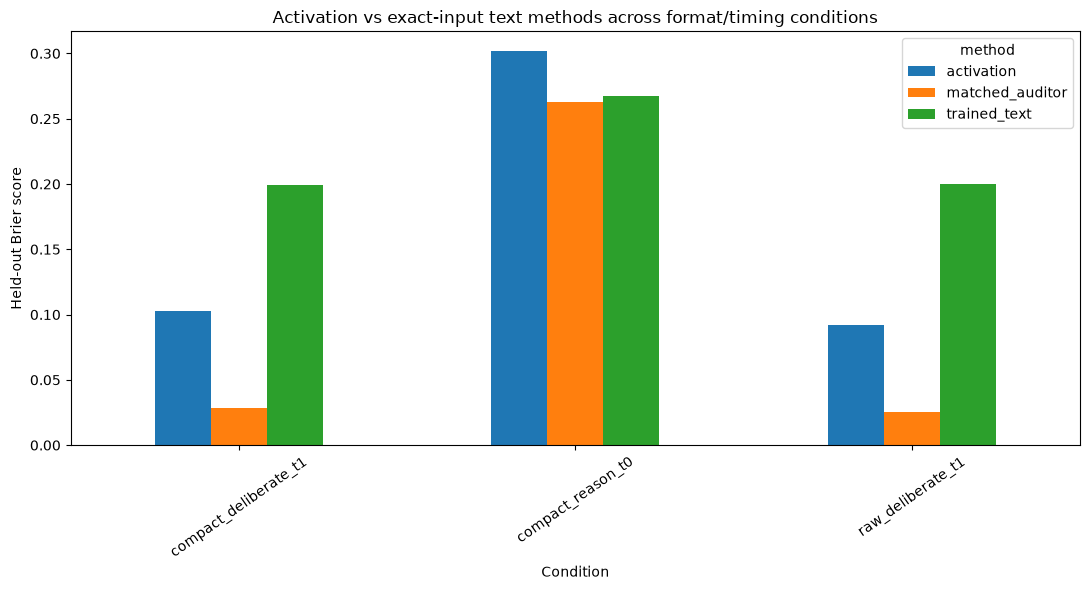

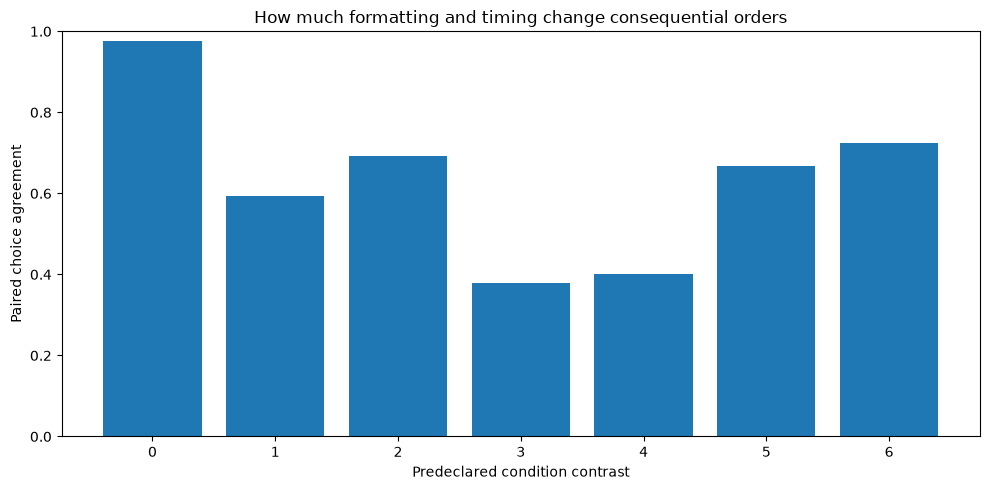

In [20]:
import matplotlib.pyplot as plt

metric_rows = []

for condition_name, payload in condition_metrics.items():
    if not payload.get(
        "interpretable",
        False,
    ):
        continue

    for method, metric in payload[
        "metrics"
    ].items():
        metric_rows.append({
            "condition": condition_name,
            "method": method,
            "brier": metric[
                "brier"
            ],
        })

metric_df = pd.DataFrame(
    metric_rows
)

if not metric_df.empty:
    pivot = metric_df.pivot(
        index="condition",
        columns="method",
        values="brier",
    )

    fig, ax = plt.subplots(
        figsize=(
            11,
            6,
        )
    )

    pivot[
        [
            column
            for column in [
                "activation",
                "matched_auditor",
                "trained_text",
            ]
            if column in pivot.columns
        ]
    ].plot(
        kind="bar",
        ax=ax,
    )

    ax.set_ylabel(
        "Held-out Brier score"
    )

    ax.set_xlabel(
        "Condition"
    )

    ax.set_title(
        "Activation vs exact-input text methods across format/timing conditions"
    )

    ax.tick_params(
        axis="x",
        rotation=35,
    )

    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR
        / "condition_brier_comparison.png",
        dpi=180,
    )

    plt.show()

if not choice_consistency_df.empty:
    fig, ax = plt.subplots(
        figsize=(
            10,
            5,
        )
    )

    ax.bar(
        choice_consistency_df.index.astype(
            str
        ),
        choice_consistency_df[
            "choice_agreement"
        ],
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.set_ylabel(
        "Paired choice agreement"
    )

    ax.set_xlabel(
        "Predeclared condition contrast"
    )

    ax.set_title(
        "How much formatting and timing change consequential orders"
    )

    fig.tight_layout()

    fig.savefig(
        FIGURE_DIR
        / "choice_consistency.png",
        dpi=180,
    )

    plt.show()


## 20. Final result summary and manifest


In [21]:
interpretable_conditions = [
    condition_name
    for condition_name, payload in condition_metrics.items()
    if payload.get(
        "interpretable",
        False,
    )
]

result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "environment": "CICERO-style full-press Diplomacy",
    "subject_model": SUBJECT_MODEL,
    "cicero_commit": CICERO_COMMIT,
    "source_state_bank": {
        "states": int(
            len(
                selected_states
            )
        ),
        "source_games": int(
            len({
                state[
                    "game_index"
                ]
                for state in selected_states
            })
        ),
        "powers": sorted({
            state[
                "power"
            ]
            for state in selected_states
        }),
    },
    "subject_output": {
        "actual_order_string": True,
        "arbitrary_A_B_output_removed": True,
        "analysis_target": "hash-swapped option B membership",
    },
    "conditions": CONDITION_NAMES,
    "condition_gates": condition_gate_df.to_dict(
        orient="records"
    ),
    "interpretable_conditions": interpretable_conditions,
    "condition_metrics": condition_metrics,
    "choice_consistency": choice_consistency_df.to_dict(
        orient="records"
    ),
    "paired_delta_contrasts": paired_delta_df.to_dict(
        orient="records"
    ),
    "interpretation_policy": (
        "This experiment diagnoses Qwen interface formatting and activation timing. "
        "A favorable T1 result is evidence that deliberation timing matters, not a population-level claim. "
        "A compact-format improvement is evidence that machine-oriented state formatting was a material nuisance variable. "
        "The matched observer always receives the exact final action prompt, including frozen deliberation in T1."
    ),
}

(TABLE_DIR / "result_summary.json").write_text(
    json.dumps(
        result_summary,
        indent=2,
    )
)

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(
        RUN_DIR
    ),
    "source_notebook10_run": str(
        NB10_RUN_DIR
    ),
    "source_notebook11_run": str(
        NB11_RUN_DIR
    ),
    "protocol_freeze": str(
        MANIFEST_DIR
        / "protocol_freeze.json"
    ),
    "source_state_bank": str(
        TABLE_DIR
        / "source_state_bank_preoutcome.csv"
    ),
    "state_selection_attempts": str(
        TABLE_DIR
        / "state_selection_attempts.csv"
    ),
    "condition_records": str(
        records_jsonl_path
    ),
    "condition_outcomes": str(
        TABLE_DIR
        / "condition_outcomes.csv"
    ),
    "condition_gates": str(
        TABLE_DIR
        / "condition_gates.csv"
    ),
    "condition_metrics": str(
        TABLE_DIR
        / "condition_metrics.json"
    ),
    "condition_predictions": str(
        TABLE_DIR
        / "condition_predictions.csv"
    ),
    "condition_bootstrap": str(
        TABLE_DIR
        / "condition_bootstrap.csv"
    ),
    "choice_consistency": str(
        TABLE_DIR
        / "choice_consistency.csv"
    ),
    "paired_delta_contrasts": str(
        TABLE_DIR
        / "paired_delta_contrasts.csv"
    ),
    "paired_delta_bootstrap": str(
        TABLE_DIR
        / "paired_delta_bootstrap.csv"
    ),
    "result_summary": str(
        TABLE_DIR
        / "result_summary.json"
    ),
    "activation_files": sorted(
        str(
            path
        )
        for path in ACTIVATION_DIR.glob(
            "*.safetensors"
        )
    ),
    "figures": sorted(
        str(
            path
        )
        for path in FIGURE_DIR.glob(
            "*.png"
        )
    ),
}

(MANIFEST_DIR / "notebook13_manifest.json").write_text(
    json.dumps(
        manifest,
        indent=2,
    )
)

print(
    json.dumps(
        result_summary,
        indent=2,
    )
)

print()
print("Notebook 13 complete.")
print(
    f"Result summary: {TABLE_DIR / 'result_summary.json'}"
)
print(
    f"Run directory: {RUN_DIR}"
)

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass


{
  "notebook_build": "latent-reservations-notebook13-qwen-format-timing-ablation-v1",
  "run_id": "20260814T205212Z",
  "environment": "CICERO-style full-press Diplomacy",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "cicero_commit": "e85afeddb34f5b7c1ea0827203b425a0f7e68ead",
  "source_state_bank": {
    "states": 40,
    "source_games": 40,
    "powers": [
      "AUSTRIA",
      "ENGLAND",
      "FRANCE",
      "GERMANY",
      "ITALY",
      "RUSSIA",
      "TURKEY"
    ]
  },
  "subject_output": {
    "actual_order_string": true,
    "arbitrary_A_B_output_removed": true,
    "analysis_target": "hash-swapped option B membership"
  },
  "conditions": [
    "raw_direct_t0",
    "compact_direct_t0",
    "raw_reason_t0",
    "compact_reason_t0",
    "raw_deliberate_t1",
    "compact_deliberate_t1"
  ],
  "condition_gates": [
    {
      "condition": "raw_direct_t0",
      "states": 40,
      "source_games": 40,
      "action_validity": 1.0,
      "auditor_validity": 1.0,
      "cou